# 3 | Distribution and autocorrelation analysis (DLS)

## Objectives:

**1.** Analyze distribution profiles across conditions

**2.** Compare carrageenan behavior in water vs medium

**3.** Evaluate qualitative evidence of multimodality / broadness

**4.** Inspect autocorrelation curves

**5.** Generate figures suitable for interpretation and manuscript development

## Initial setup

### Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt

### Pandas config

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

### Project paths

In [4]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
EXP_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'src' / 'kirsten.mplstyle'
DATA_PROCESSED_DIR = EXP_DIR / 'data' / 'processed'
FIGURES_DIR = EXP_DIR / "outputs" / "figures"

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", EXP_DIR)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\dls-analysis
EXP_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution
DATA_PROCESSED_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\processed


### Load processed data

In [5]:
df_dls_main          = pd.read_csv(DATA_PROCESSED_DIR / "dls_main.csv")
df_distribution_long = pd.read_csv(DATA_PROCESSED_DIR / "distribution_long.csv")
df_correlations_long = pd.read_csv(DATA_PROCESSED_DIR / "correlations_long.csv")
df_qc                = pd.read_csv(DATA_PROCESSED_DIR / "dls_qc.csv")
df_filtered          = pd.read_csv(DATA_PROCESSED_DIR / "dls_filtered.csv")

In [6]:
df_distribution_long = df_distribution_long.merge(
    df_dls_main[
        ["Sample_Name", "carrageenan", "concentration_label", "matrix"]
    ],
    on="Sample_Name",
    how="left"
)

In [7]:
print("df_dls_main:", df_dls_main.shape)
print("df_distribution_long:", df_distribution_long.shape)
print("df_correlations_long:", df_correlations_long.shape)
print("df_filtered:", df_filtered.shape)

df_dls_main: (34, 22)
df_distribution_long: (1709, 18)
df_correlations_long: (8640, 4)
df_filtered: (28, 26)


### Quick inspection

In [8]:
display(df_distribution_long.head())
display(df_correlations_long.head())

,Sample_Name,point_index,distribution_fit,distribution_fit_data,distribution_delay_time,sample_name_raw,sample_base,carrageenan_code,carrageenan_x,concentration_value,concentration_unit,concentration_label_x,matrix_x,replicate,is_mean,carrageenan_y,concentration_label_y,matrix_y
0,k_1s-100ug_mL 1,1,0.303,0.302,1.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False,kappa,100 ug/mL,water
1,k_1s-100ug_mL 1,2,0.303,0.305,2.0,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False,kappa,100 ug/mL,water
2,k_1s-100ug_mL 1,3,0.302,0.302,2.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False,kappa,100 ug/mL,water
3,k_1s-100ug_mL 1,4,0.302,0.301,3.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False,kappa,100 ug/mL,water
4,k_1s-100ug_mL 1,5,0.302,0.302,4.5,k_1s-100ug_mL 1,k_1s-100ug_mL,k,kappa,100.0,ug/mL,100 ug/mL,water,1.0,False,kappa,100 ug/mL,water


,Sample_Name,point_index,correlation_value,delay_time_s
0,k_1s-100ug_mL 1,1,0.0897,0.5
1,k_1s-100ug_mL 1,2,0.0946,1.0
2,k_1s-100ug_mL 1,3,0.0952,1.5
3,k_1s-100ug_mL 1,4,0.0967,2.0
4,k_1s-100ug_mL 1,5,0.0949,2.5


### Check available columns

In [9]:
print("distribution columns:")
print(df_distribution_long.columns.tolist())

print("\ncorrelation columns:")
print(df_correlations_long.columns.tolist())

distribution columns:
['Sample_Name', 'point_index', 'distribution_fit', 'distribution_fit_data', 'distribution_delay_time', 'sample_name_raw', 'sample_base', 'carrageenan_code', 'carrageenan_x', 'concentration_value', 'concentration_unit', 'concentration_label_x', 'matrix_x', 'replicate', 'is_mean', 'carrageenan_y', 'concentration_label_y', 'matrix_y']

correlation columns:
['Sample_Name', 'point_index', 'correlation_value', 'delay_time_s']


In [10]:
metadata_cols = [
    "Sample_Name",
    "sample_base",
    "carrageenan",
    "concentration_label",
    "matrix",
    "replicate"
]

# remover metadados antigos/incompletos, se existirem
cols_to_drop = [
    "sample_base",
    "carrageenan",
    "concentration_label",
    "matrix",
    "replicate"
]

df_dist = df_distribution_long.drop(
    columns=[c for c in cols_to_drop if c in df_distribution_long.columns]
).copy()

# fazer merge com metadados confiáveis vindos de df_dls_main
df_dist = df_dist.merge(
    df_dls_main[metadata_cols],
    on="Sample_Name",
    how="left"
)

print(df_dist.shape)
print(df_dist.columns.tolist())
display(df_dist.head())

(1709, 21)
['Sample_Name', 'point_index', 'distribution_fit', 'distribution_fit_data', 'distribution_delay_time', 'sample_name_raw', 'carrageenan_code', 'carrageenan_x', 'concentration_value', 'concentration_unit', 'concentration_label_x', 'matrix_x', 'is_mean', 'carrageenan_y', 'concentration_label_y', 'matrix_y', 'sample_base', 'carrageenan', 'concentration_label', 'matrix', 'replicate']


,Sample_Name,point_index,distribution_fit,distribution_fit_data,distribution_delay_time,sample_name_raw,carrageenan_code,carrageenan_x,concentration_value,concentration_unit,concentration_label_x,matrix_x,is_mean,carrageenan_y,concentration_label_y,matrix_y,sample_base,carrageenan,concentration_label,matrix,replicate
0,k_1s-100ug_mL 1,1,0.303,0.302,1.5,k_1s-100ug_mL 1,k,kappa,100.0,ug/mL,100 ug/mL,water,False,kappa,100 ug/mL,water,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
1,k_1s-100ug_mL 1,2,0.303,0.305,2.0,k_1s-100ug_mL 1,k,kappa,100.0,ug/mL,100 ug/mL,water,False,kappa,100 ug/mL,water,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
2,k_1s-100ug_mL 1,3,0.302,0.302,2.5,k_1s-100ug_mL 1,k,kappa,100.0,ug/mL,100 ug/mL,water,False,kappa,100 ug/mL,water,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
3,k_1s-100ug_mL 1,4,0.302,0.301,3.5,k_1s-100ug_mL 1,k,kappa,100.0,ug/mL,100 ug/mL,water,False,kappa,100 ug/mL,water,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
4,k_1s-100ug_mL 1,5,0.302,0.302,4.5,k_1s-100ug_mL 1,k,kappa,100.0,ug/mL,100 ug/mL,water,False,kappa,100 ug/mL,water,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0


In [11]:
df_dist[[
    "Sample_Name",
    "sample_base",
    "carrageenan",
    "concentration_label",
    "matrix",
    "replicate"
]].head()

,Sample_Name,sample_base,carrageenan,concentration_label,matrix,replicate
0,k_1s-100ug_mL 1,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
1,k_1s-100ug_mL 1,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
2,k_1s-100ug_mL 1,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
3,k_1s-100ug_mL 1,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0
4,k_1s-100ug_mL 1,k_1s-100ug_mL,kappa,100 ug/mL,water,1.0


## Subdatasets preparation

### Distributions per group

In [12]:
df_dist_water = df_dist[
    (df_dist["matrix"] == "water") &
    (df_dist["carrageenan"].notna())
].copy()

df_dist_medium = df_dist[
    (df_dist["matrix"] == "medium") &
    (df_dist["carrageenan"].notna())
].copy()

df_dist_control = df_dist[
    df_dist["carrageenan"].isna()
].copy()

print("water:", df_dist_water.shape)
print("medium:", df_dist_medium.shape)
print("control:", df_dist_control.shape)

water: (720, 21)
medium: (318, 21)
control: (671, 21)


### Correlation per group

In [13]:
df_corr = df_correlations_long.merge(
    df_filtered[["Sample_Name", "sample_base", "carrageenan", "matrix", "concentration_label", "replicate"]],
    on="Sample_Name",
    how="left"
)

df_corr_water = df_corr[
    (df_corr["matrix"] == "water") &
    (df_corr["carrageenan"].notna())
].copy()

df_corr_medium = df_corr[
    (df_corr["matrix"] == "medium") &
    (df_corr["carrageenan"].notna())
].copy()

df_corr_control = df_corr[
    df_corr["carrageenan"].isna()
].copy()

print("water:", df_corr_water.shape)
print("medium:", df_corr_medium.shape)
print("control:", df_corr_control.shape)

water: (2880, 9)
medium: (1728, 9)
control: (4032, 9)


# **Distributions**: global inspection

### Points per sample

In [14]:
dist_points = (
    df_dist
    .groupby("Sample_Name")
    .size()
    .reset_index(name="n_points")
    .sort_values("n_points")
)

display(dist_points.head(20))
display(dist_points.tail(20))

,Sample_Name,n_points
18,aMEM_10pct-L_3s 3,10
22,aMEM_10pct-i_2s 3,28
14,aMEM_10pct-Ctrl 3,31
0,L_3S-1mg_mL 1,40
4,L_3S-35ug_mL 1,40
5,L_3S-35ug_mL 2,40
2,L_3S-1mg_mL 3,40
1,L_3S-1mg_mL 2,40
7,L_3S-35ug_mL-mean,40
8,aMEM-Ctrl 1,40


,Sample_Name,n_points
24,aMEM_10pct-k_1s 1,40
25,aMEM_10pct-k_1s 2,40
26,aMEM_10pct-k_1s 3,40
27,aMEM_10pct-k_1s-mean,40
28,i_2S-1mg_mL 1,40
29,i_2S-1mg_mL 2,40
30,i_2S-1mg_mL 3,40
31,i_2S-1mg_mL-mean,40
32,i_2S-20ug_mL 1,40
33,i_2S-20ug_mL 2,40


### Check distribution variables range

In [15]:
df_dist[[
    "distribution_fit",
    "distribution_fit_data",
    "distribution_delay_time"
]].describe()

,distribution_fit,distribution_fit_data,distribution_delay_time
count,1709.000000,1709.000000,1709.000000
mean,0.533592,0.489567,250.316132
std,0.319169,0.347656,1083.554102
min,0.002850,0.000030,0.010300
25%,0.255000,0.117000,0.337000
50%,0.570000,0.528000,7.500000
75%,0.838000,0.831000,68.500000
max,1.050000,1.050000,14300.000000


### First visual diagnostic of a sample per group

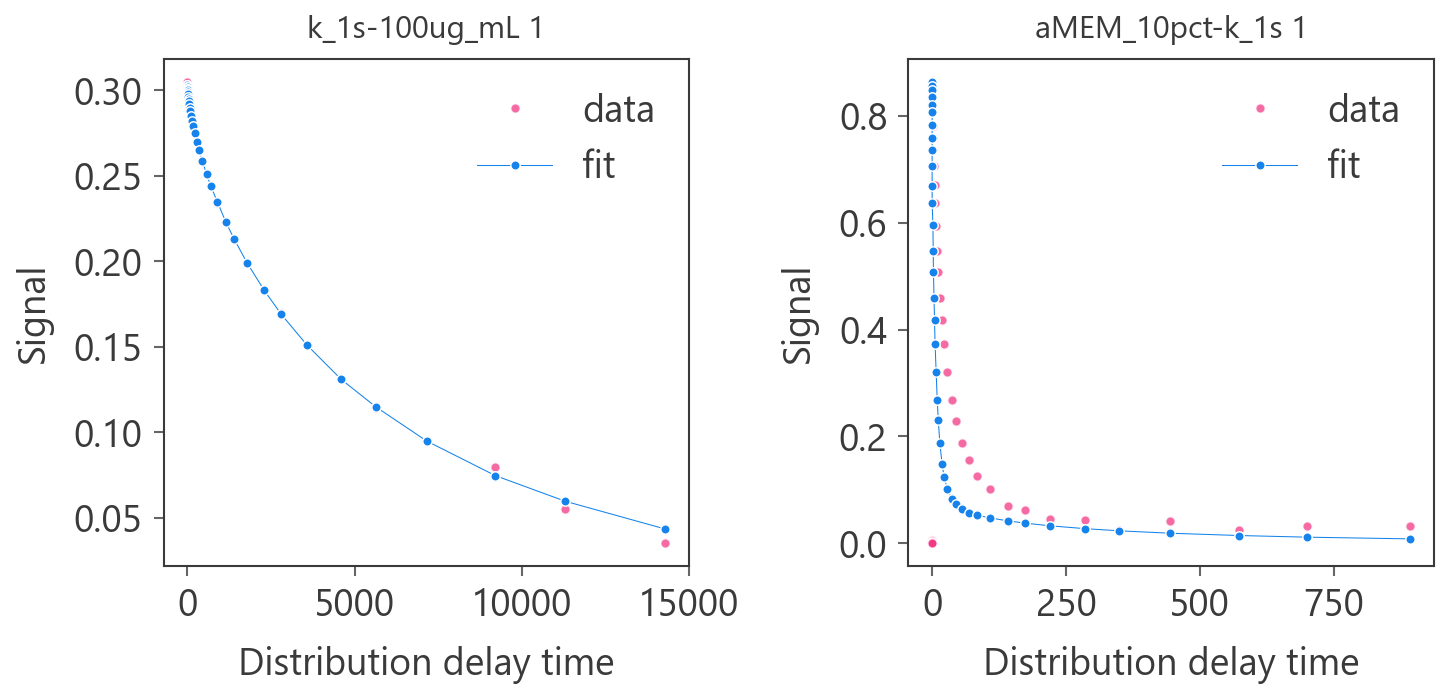

In [16]:
example_water = df_dist_water["Sample_Name"].dropna().unique()[0]
example_medium = df_dist_medium["Sample_Name"].dropna().unique()[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

tmp = df_dist_water[df_dist_water["Sample_Name"] == example_water]
axes[0].set_title(example_water)
axes[0].set_xlabel("Distribution delay time"); axes[0].set_ylabel("Signal")

axes[0].plot(tmp["distribution_delay_time"], tmp["distribution_fit_data"], marker='o', ls='', alpha=.75, label="data")
axes[0].plot(tmp["distribution_delay_time"], tmp["distribution_fit"], label="fit")
axes[0].legend()

tmp = df_dist_medium[df_dist_medium["Sample_Name"] == example_medium]
axes[1].set_title(example_medium)
axes[1].set_xlabel("Distribution delay time"); axes[1].set_ylabel("Signal")

axes[1].plot(tmp["distribution_delay_time"], tmp["distribution_fit_data"], marker='o', ls='', alpha=.75, label="data")
axes[1].plot(tmp["distribution_delay_time"], tmp["distribution_fit"],      label="fit")
axes[1].legend()

plt.tight_layout()

## Distributions overlapping per matrix and carrageenan

### Function to plot individual curves

In [17]:
def plot_distribution_curves(
    df,
    title="Distribution curves",
    value_col="distribution_fit_data",
    x_col="distribution_delay_time",
    group_col="Sample_Name",
    alpha=0.5
):
    plt.figure(figsize=(8, 5))
    
    for sample_name, subdf in df.groupby(group_col):
        subdf = subdf.sort_values(x_col)
        plt.plot(subdf[x_col], subdf[value_col], alpha=alpha)

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(value_col)
    # plt.xscale('log')
    plt.tight_layout()

### All distributions in water

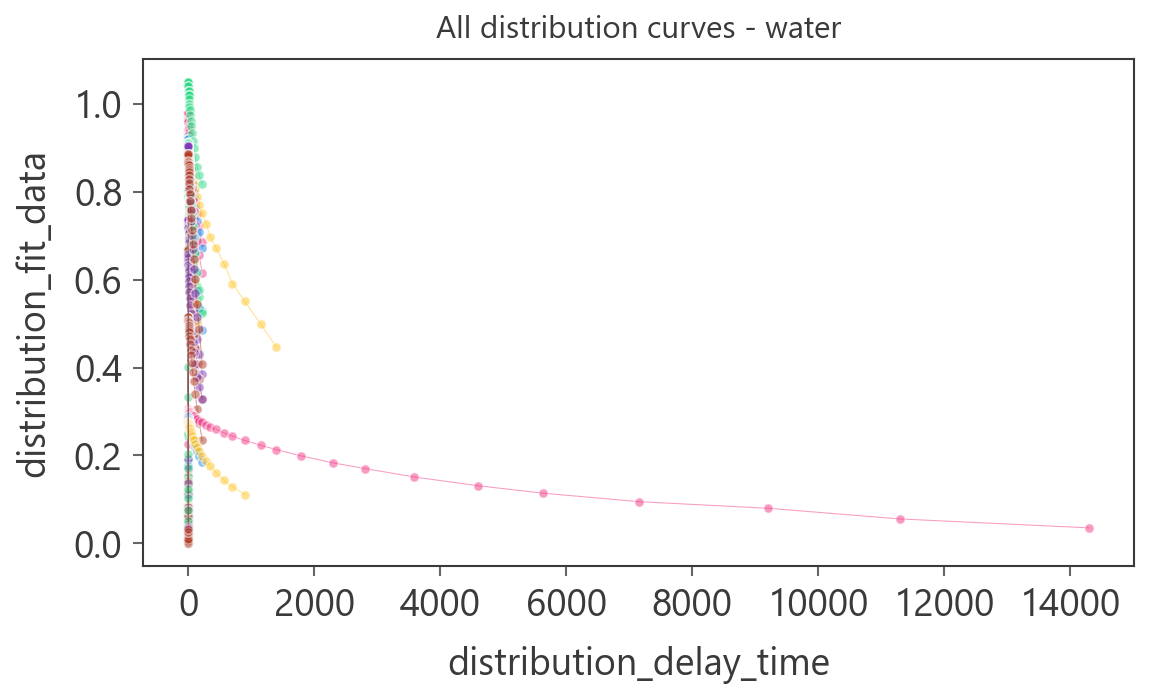

In [18]:
plot_distribution_curves(
    df_dist_water,
    title="All distribution curves - water",
    value_col="distribution_fit_data"
)

### All distributions in media

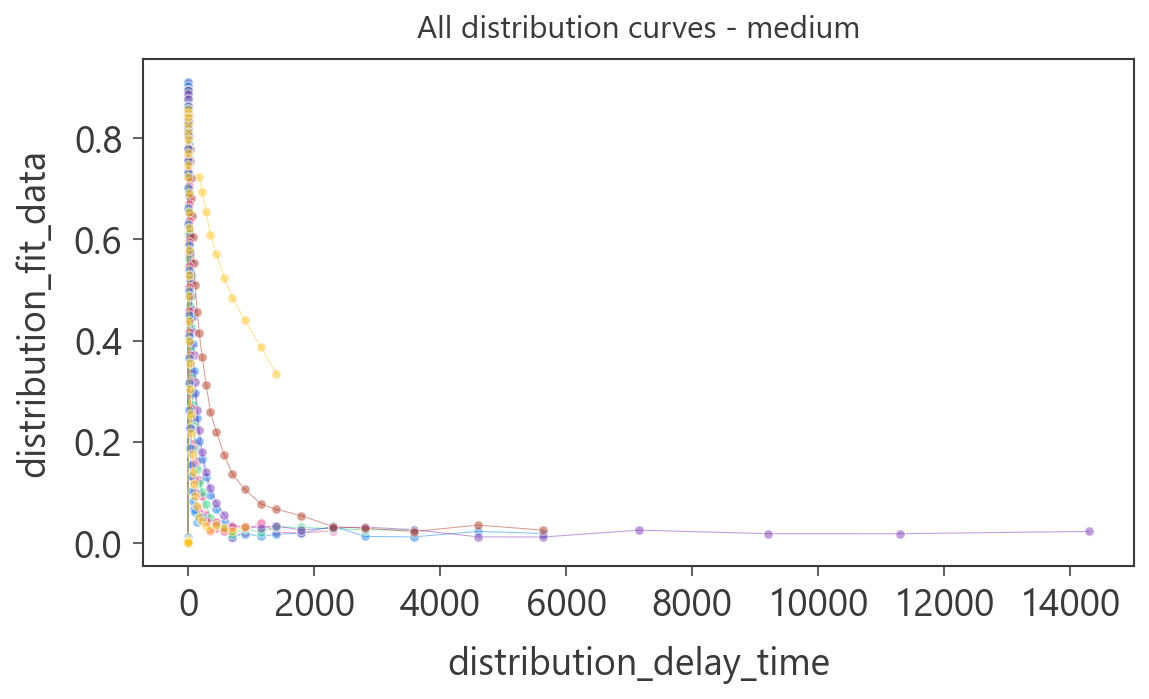

In [19]:
plot_distribution_curves(
    df_dist_medium,
    title="All distribution curves - medium",
    value_col="distribution_fit_data"
)

### Per carrageenan in water

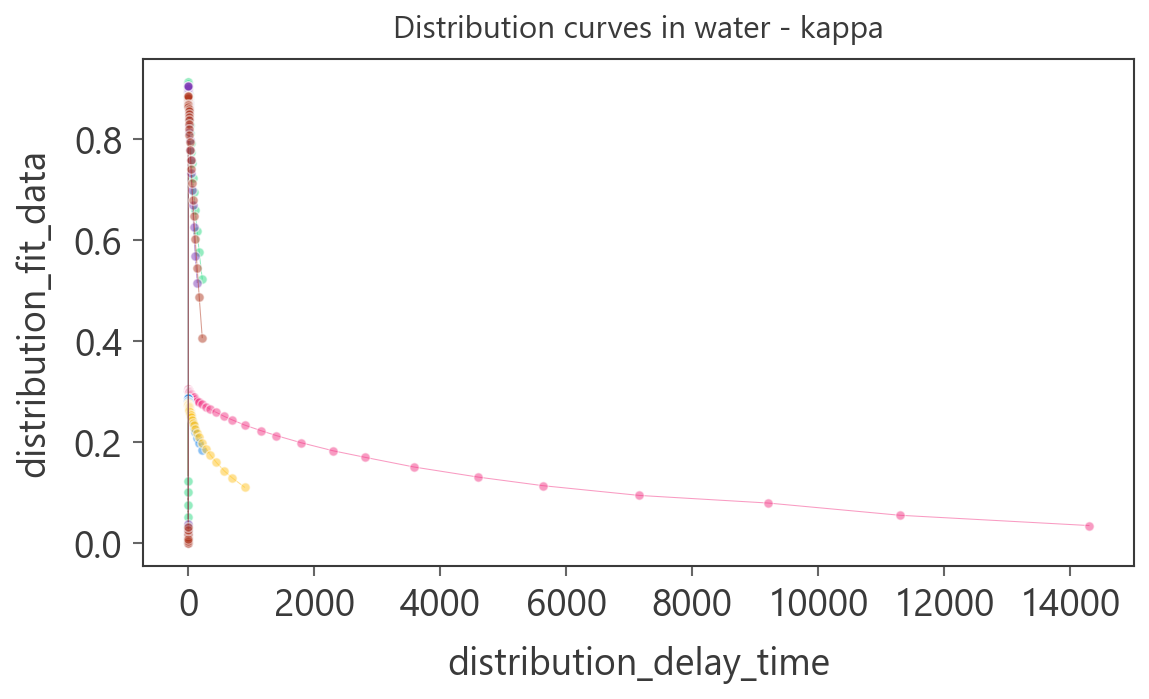

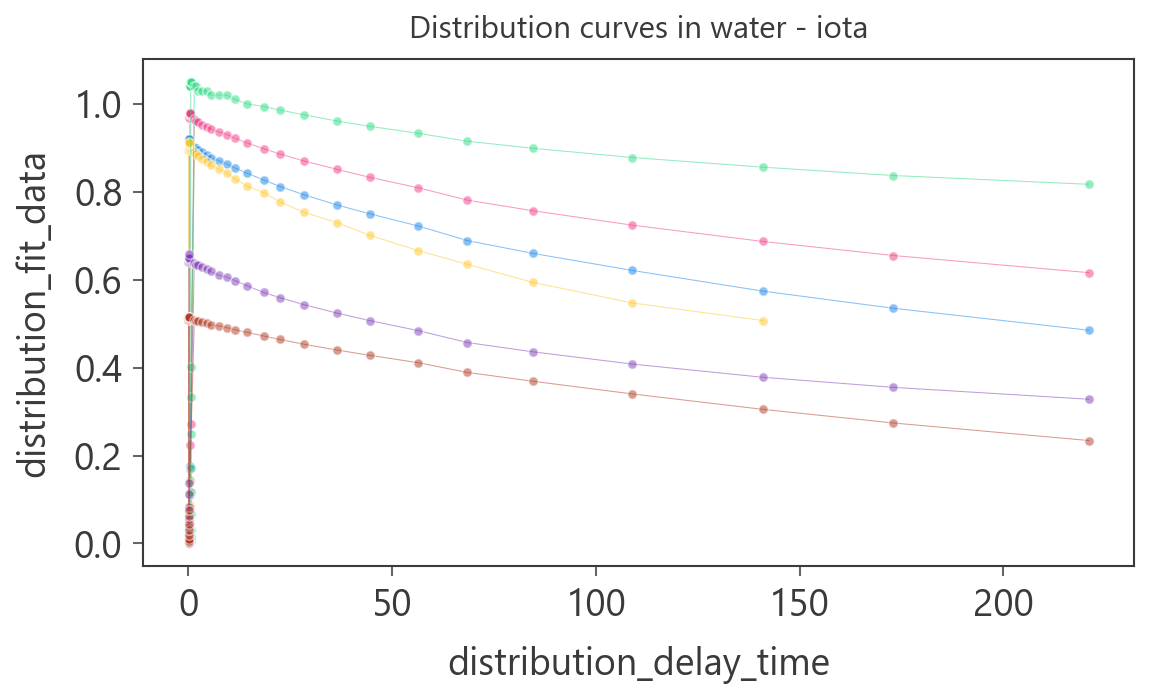

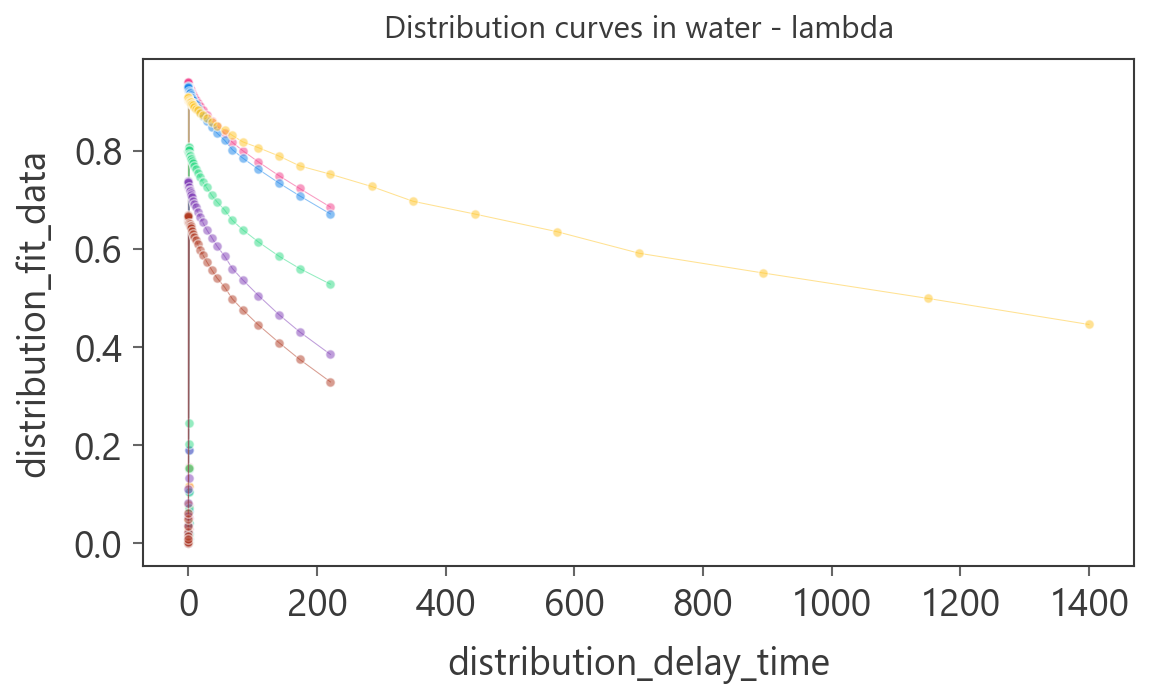

In [20]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = df_dist_water[df_dist_water["carrageenan"] == carr]
    if len(tmp) > 0:
        plot_distribution_curves(
            tmp,
            title=f"Distribution curves in water - {carr}",
            value_col="distribution_fit_data"
        )

### Per carrageenan in media

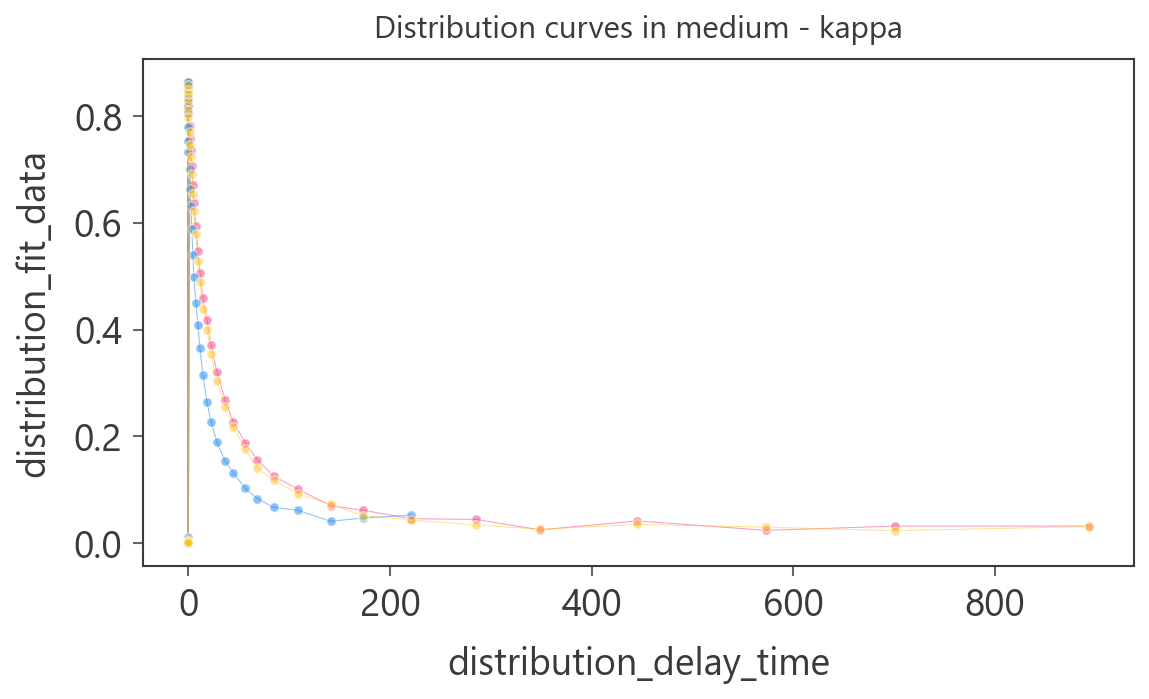

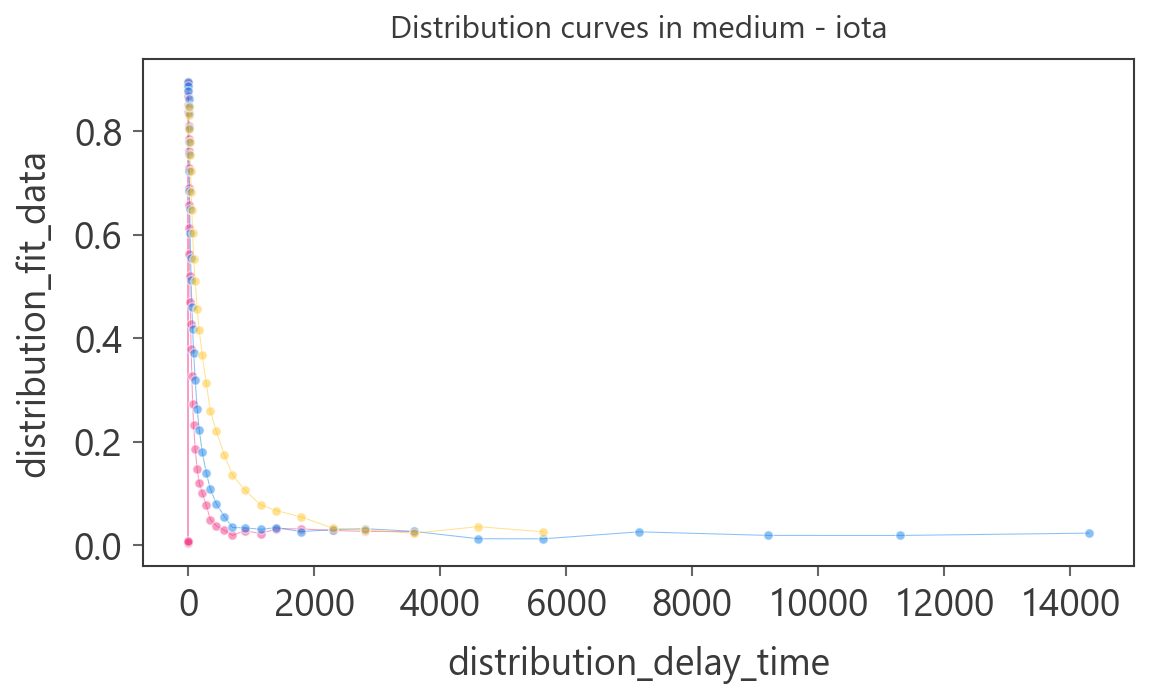

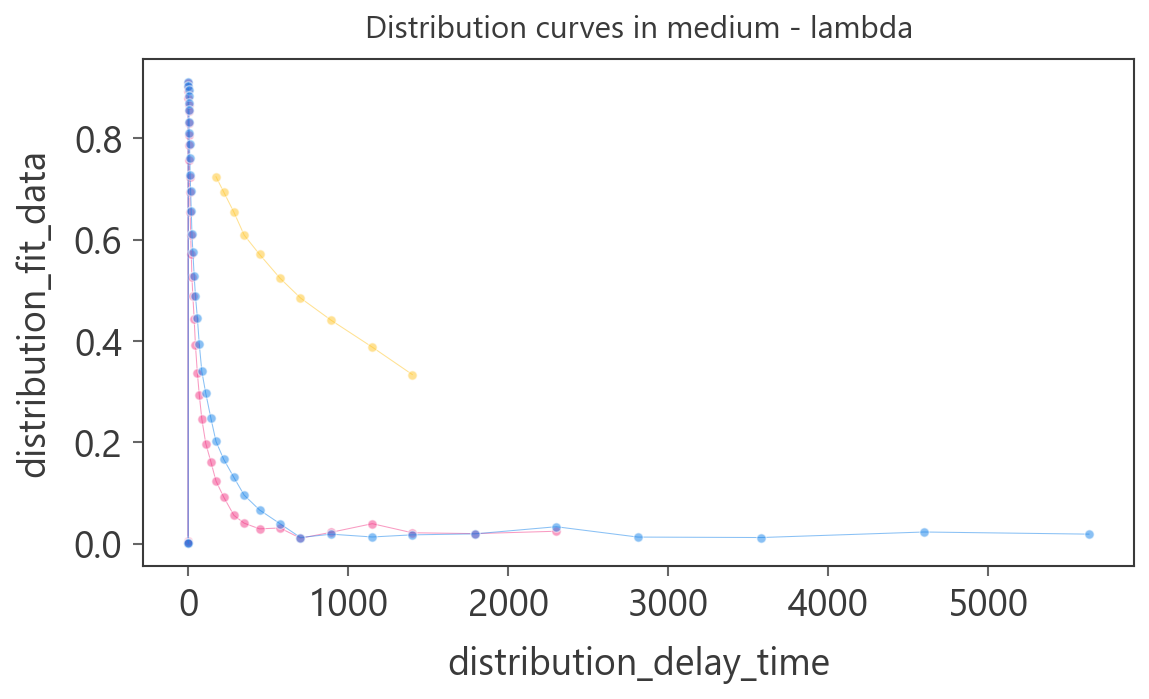

In [21]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = df_dist_medium[df_dist_medium["carrageenan"] == carr]
    if len(tmp) > 0:
        plot_distribution_curves(
            tmp,
            title=f"Distribution curves in medium - {carr}",
            value_col="distribution_fit_data"
        )

## Mean distribution profiles 

Mean curves per condition

### Mean per `sample_base` and `point_index`

In [22]:
dist_profile = (
    df_dist
    .groupby([
        "sample_base",
        "carrageenan",
        "concentration_label",
        "matrix",
        "point_index"
    ], dropna=False)
    .agg(
        x_mean=("distribution_delay_time", "mean"),
        y_mean=("distribution_fit_data", "mean"),
        y_std=("distribution_fit_data", "std"),
        n=("distribution_fit_data", "count")
    )
    .reset_index()
)

display(dist_profile.head())

,sample_base,carrageenan,concentration_label,matrix,point_index,x_mean,y_mean,y_std,n
0,L_3S-1mg_mL,lambda,1 mg/mL,water,1,0.556333,0.178667,0.021362,3
1,L_3S-1mg_mL,lambda,1 mg/mL,water,2,0.511333,0.141333,0.020306,3
2,L_3S-1mg_mL,lambda,1 mg/mL,water,3,0.456333,0.100467,0.017951,3
3,L_3S-1mg_mL,lambda,1 mg/mL,water,4,0.404333,0.064567,0.014801,3
4,L_3S-1mg_mL,lambda,1 mg/mL,water,5,0.354667,0.041767,0.011473,3


In [23]:
dist_profile_clean = (
    dist_profile
    .groupby(
        ["matrix", "carrageenan", "concentration_label", "point_index"],
        dropna=False,
        as_index=False
    )
    .agg(
        x_mean=("x_mean", "mean"),
        y_mean=("y_mean", "mean"),
        y_std=("y_mean", "std"),
        n=("y_mean", "count")
    )
)

display(dist_profile_clean.head())

,matrix,carrageenan,concentration_label,point_index,x_mean,y_mean,y_std,n
0,medium,iota,20 ug/mL,1,4.341533,0.583297,NaN,1
1,medium,iota,20 ug/mL,2,5.507700,0.575427,NaN,1
2,medium,iota,20 ug/mL,3,7.006600,0.561940,NaN,1
3,medium,iota,20 ug/mL,4,8.675267,0.845000,NaN,1
4,medium,iota,20 ug/mL,5,11.007167,0.830667,NaN,1


### Function to plot mean profile

In [24]:
def plot_mean_distribution_profile(
    df,
    title="",
    hue_col="concentration_label",
    x_col="x_mean",
    y_col="y_mean",
    normalize=True,
    xlim=(1, 2000),
    ylim=(0.2, 1.05)
):
    plt.figure(figsize=(10, 5))

    for label, subdf in df.groupby(hue_col, dropna=False):
        subdf = (
            subdf
            .sort_values(x_col)
            .groupby(x_col, as_index=False)[y_col]
            .mean()
        )

        x = subdf[x_col]
        y = subdf[y_col].copy()

        if normalize and y.max() != 0:
            y = y / y.max()

        plt.plot(x, y, label=label)

    plt.xscale("log")
    plt.xlim(*xlim)
    plt.ylim(*ylim)

    plt.xlabel("Distribution delay time")
    plt.ylabel("Normalized distribution signal" if normalize else "Mean distribution signal")
    plt.title(title)
    plt.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Mean profiles in water

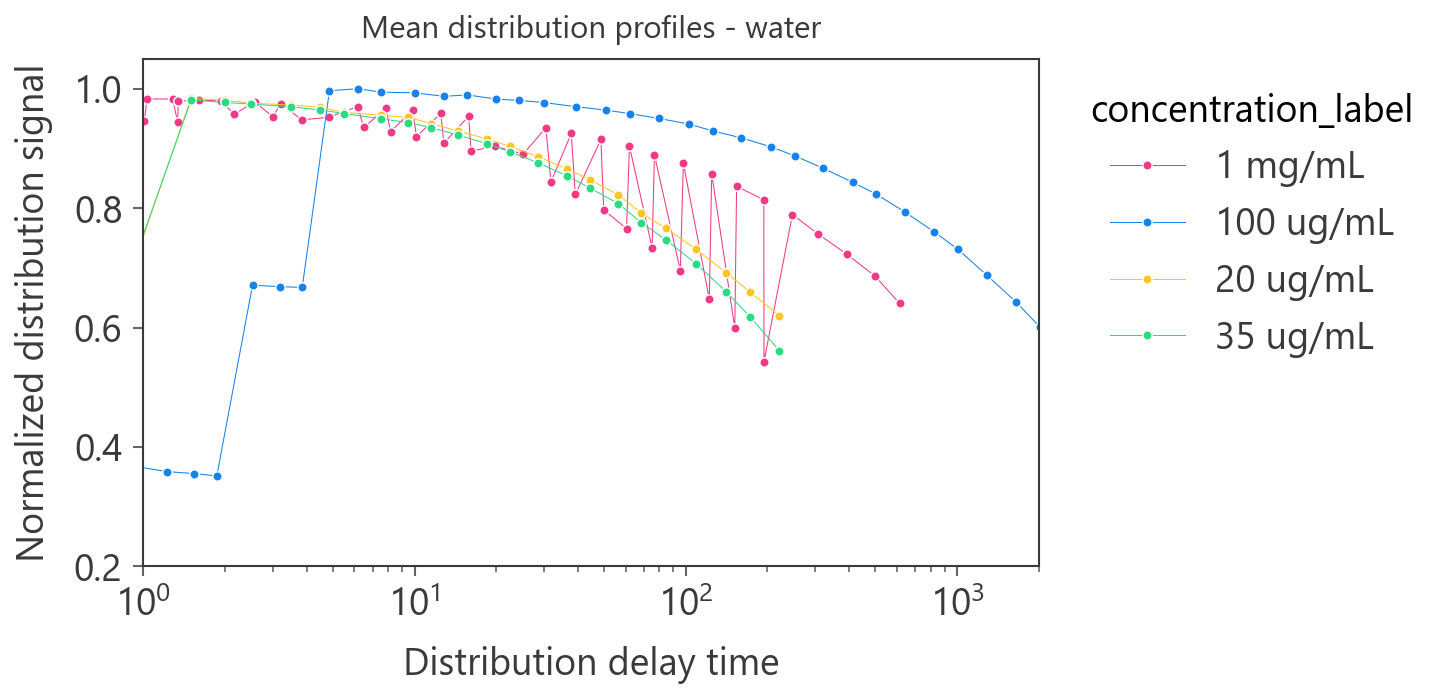

In [25]:
plot_mean_distribution_profile(
    dist_profile[
        (dist_profile["matrix"] == "water") &
        (dist_profile["carrageenan"].notna())
    ],
    title="Mean distribution profiles - water"
)

### Mean profiles in media

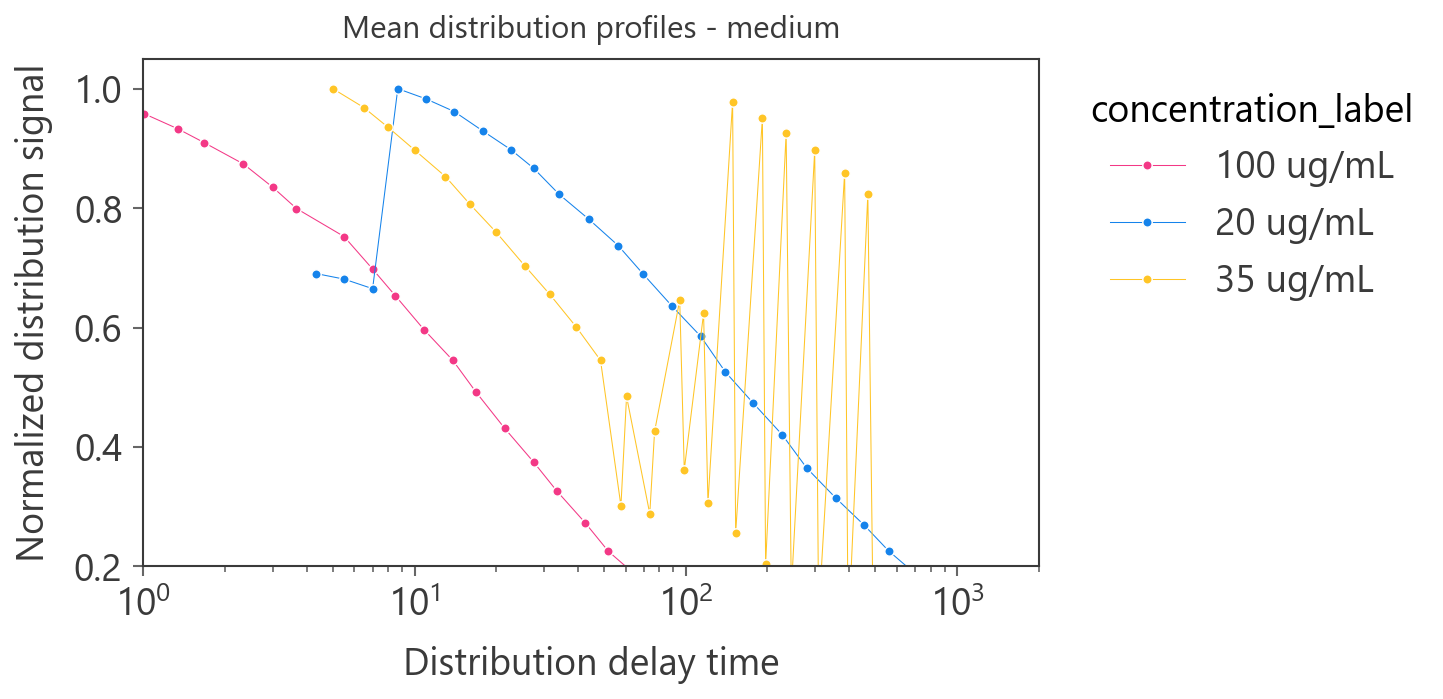

In [26]:
plot_mean_distribution_profile(
    dist_profile[
        (dist_profile["matrix"] == "medium") &
        (dist_profile["carrageenan"].notna())
    ],
    title="Mean distribution profiles - medium"
)

### Mean profiles per carrageenan in water

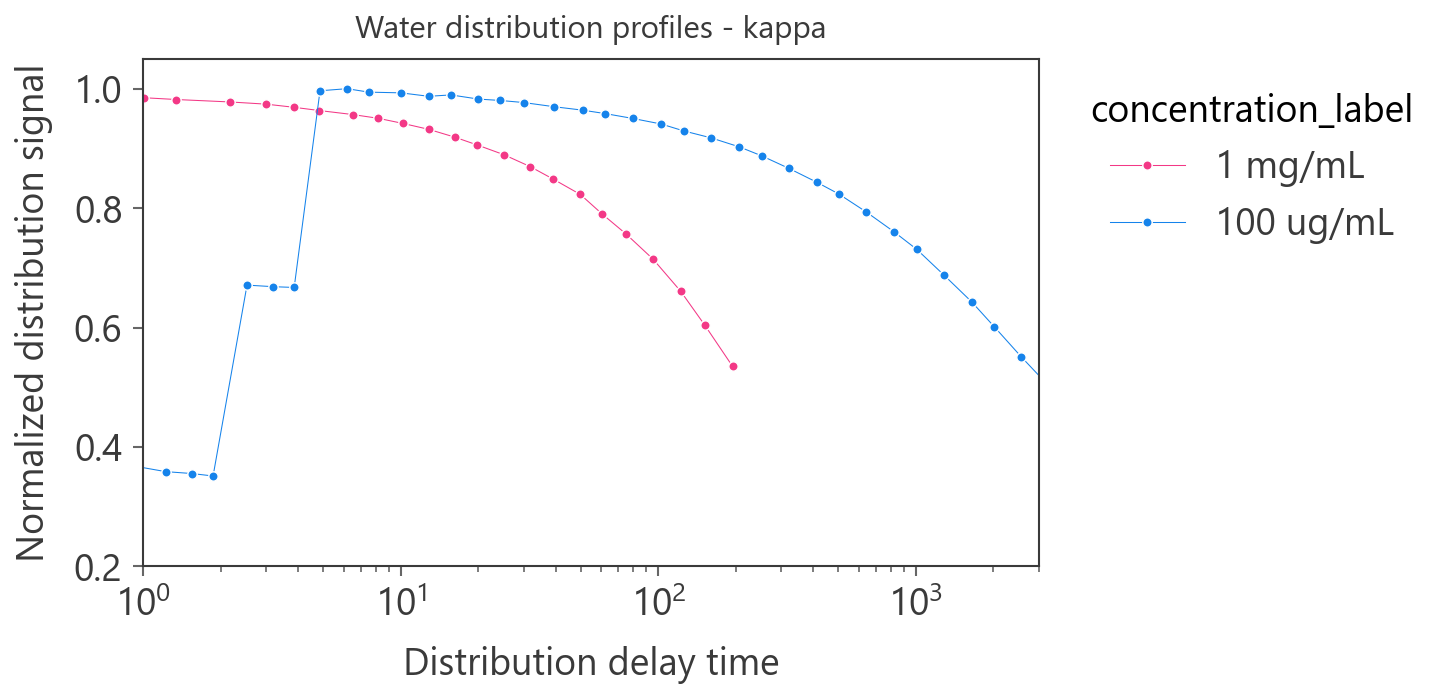

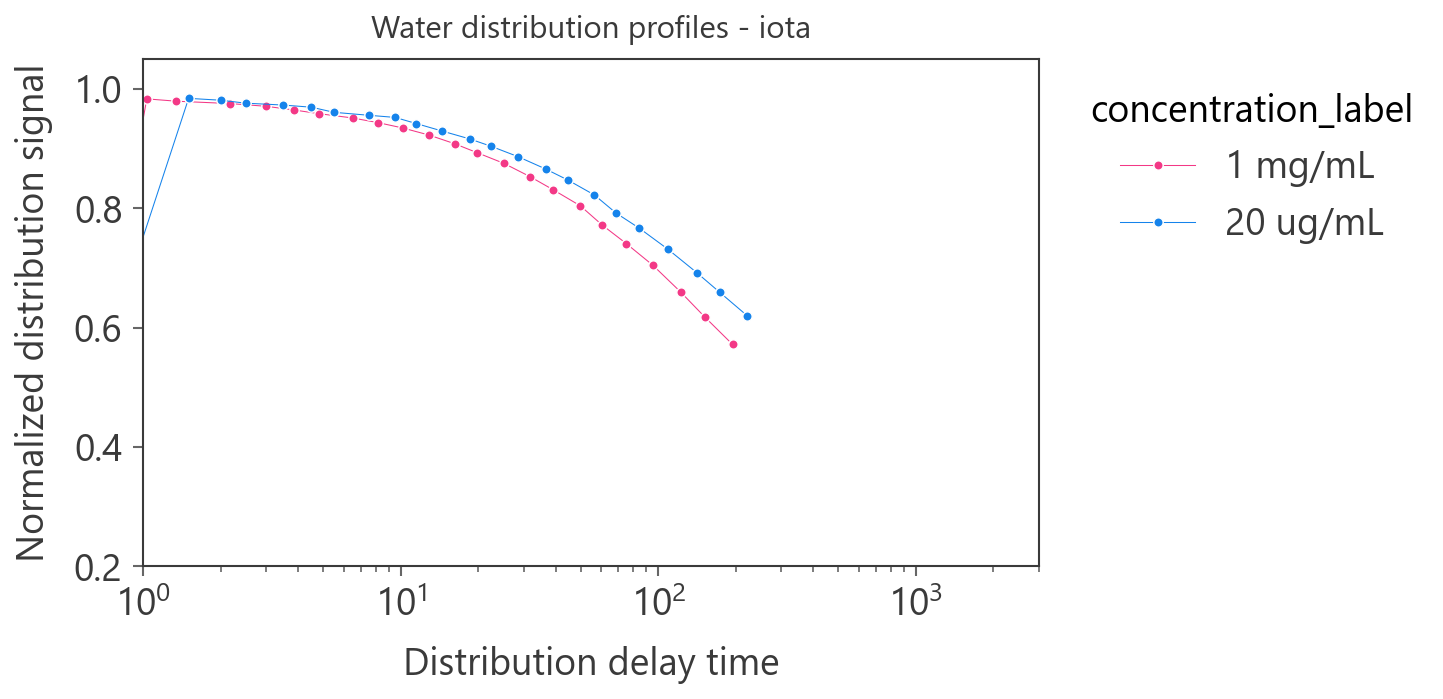

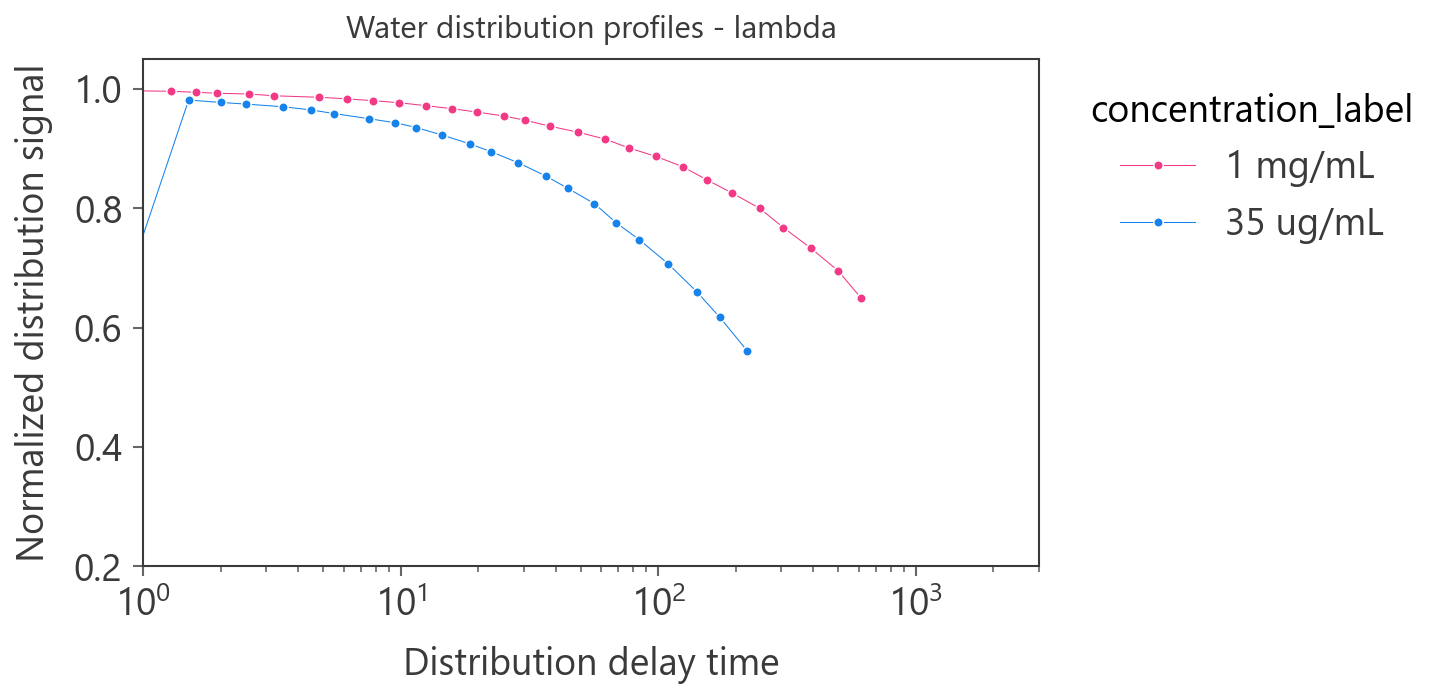

In [27]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = dist_profile_clean[
        (dist_profile_clean["matrix"] == "water") &
        (dist_profile_clean["carrageenan"] == carr)
    ]

    plot_mean_distribution_profile(
        tmp,
        title=f"Water distribution profiles - {carr}",
        hue_col="concentration_label",
        xlim=(1, 3000),
        ylim=(0.2, 1.05)
    )

### Mean profiles per carrageenan in media

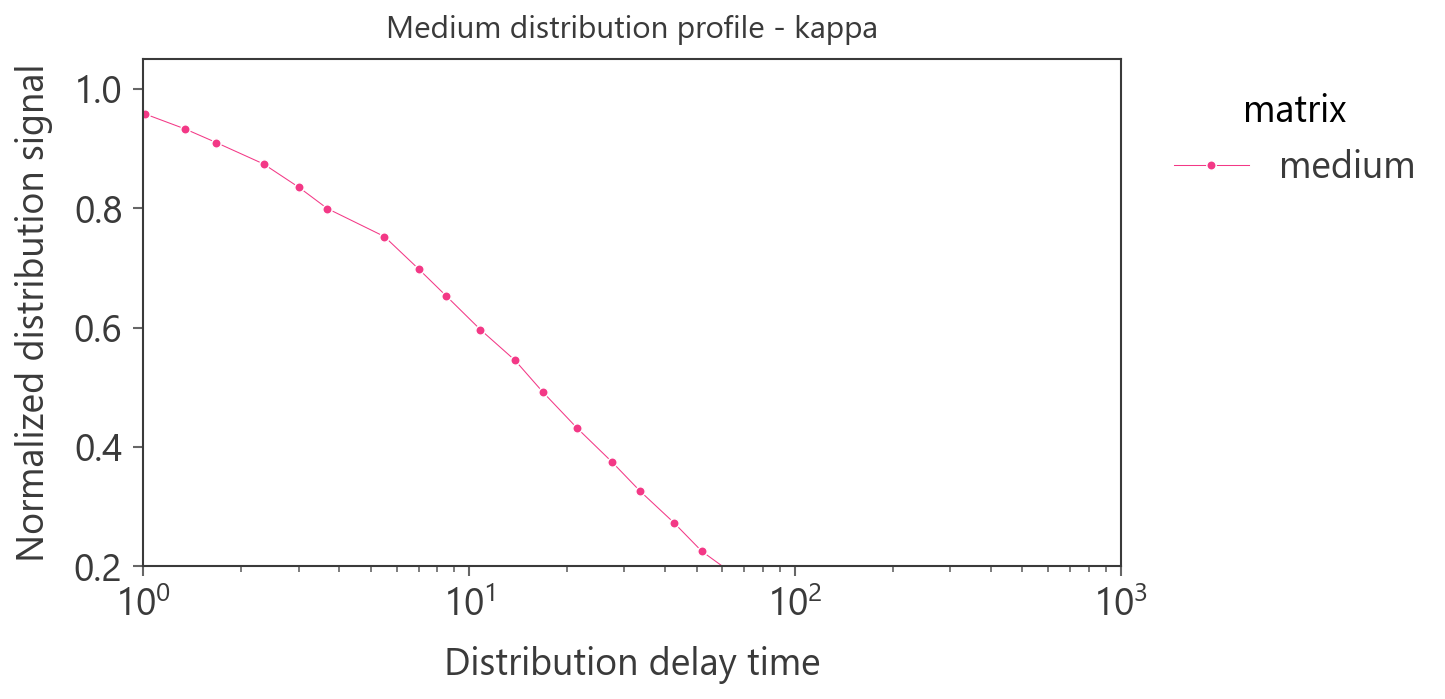

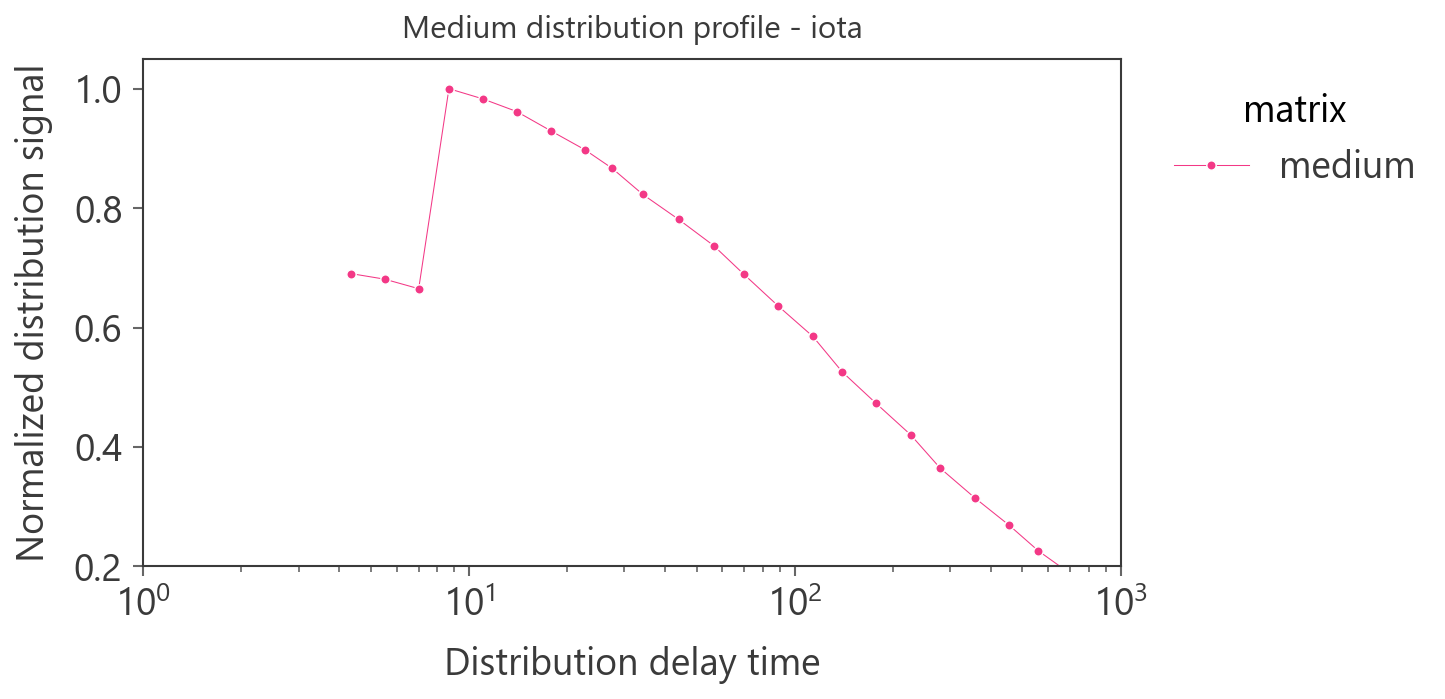

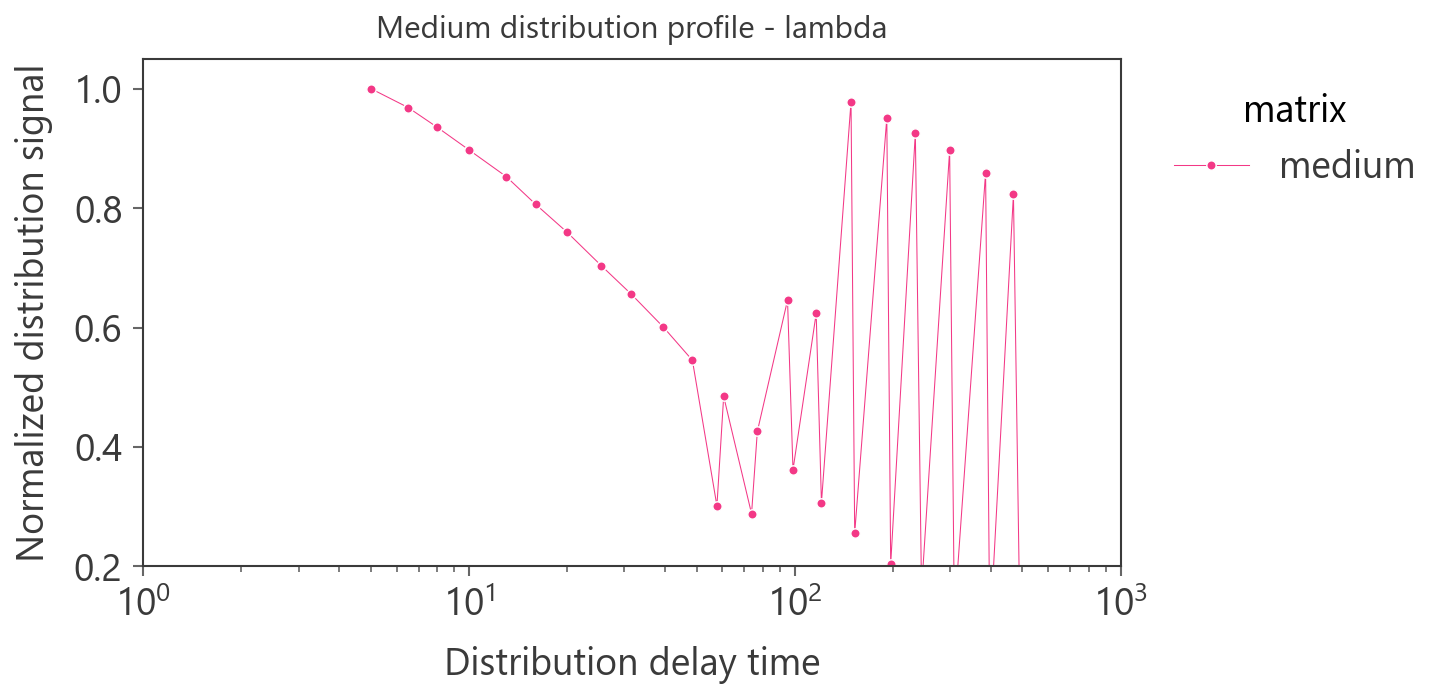

In [28]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = dist_profile_clean[
        (dist_profile_clean["matrix"] == "medium") &
        (dist_profile_clean["carrageenan"] == carr)
    ]

    plot_mean_distribution_profile(
        tmp,
        title=f"Medium distribution profile - {carr}",
        hue_col="matrix",
        xlim=(1, 1000),
        ylim=(0.2, 1.05)
    )

### Water vs Medium

In [29]:
def plot_water_concentrations_vs_medium(carr, xlim=(1, 3000), ylim=(0.2, 1.05)):
    plt.figure(figsize=(10, 5))

    # water: separado por concentração
    water = dist_profile_clean[
        (dist_profile_clean["matrix"] == "water") &
        (dist_profile_clean["carrageenan"] == carr)
    ]

    for conc, subdf in water.groupby("concentration_label", dropna=False):
        subdf = (
            subdf.sort_values("x_mean")
            .groupby("x_mean", as_index=False)["y_mean"]
            .mean()
        )

        y = subdf["y_mean"]
        if y.max() != 0:
            y = y / y.max()

        plt.plot(subdf["x_mean"], y, label=f"water - {conc}")

    # medium: uma curva única
    medium = dist_profile_clean[
        (dist_profile_clean["matrix"] == "medium") &
        (dist_profile_clean["carrageenan"] == carr)
    ]

    subdf = (
        medium.sort_values("x_mean")
        .groupby("x_mean", as_index=False)["y_mean"]
        .mean()
    )

    y = subdf["y_mean"]
    if y.max() != 0:
        y = y / y.max()

    plt.plot(subdf["x_mean"], y, label="medium", linestyle="--")

    plt.xscale("log")
    plt.xlim(*xlim)
    plt.ylim(*ylim)

    plt.xlabel("Distribution delay time")
    plt.ylabel("Normalized distribution signal")
    plt.title(f"Distribution profiles - {carr}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

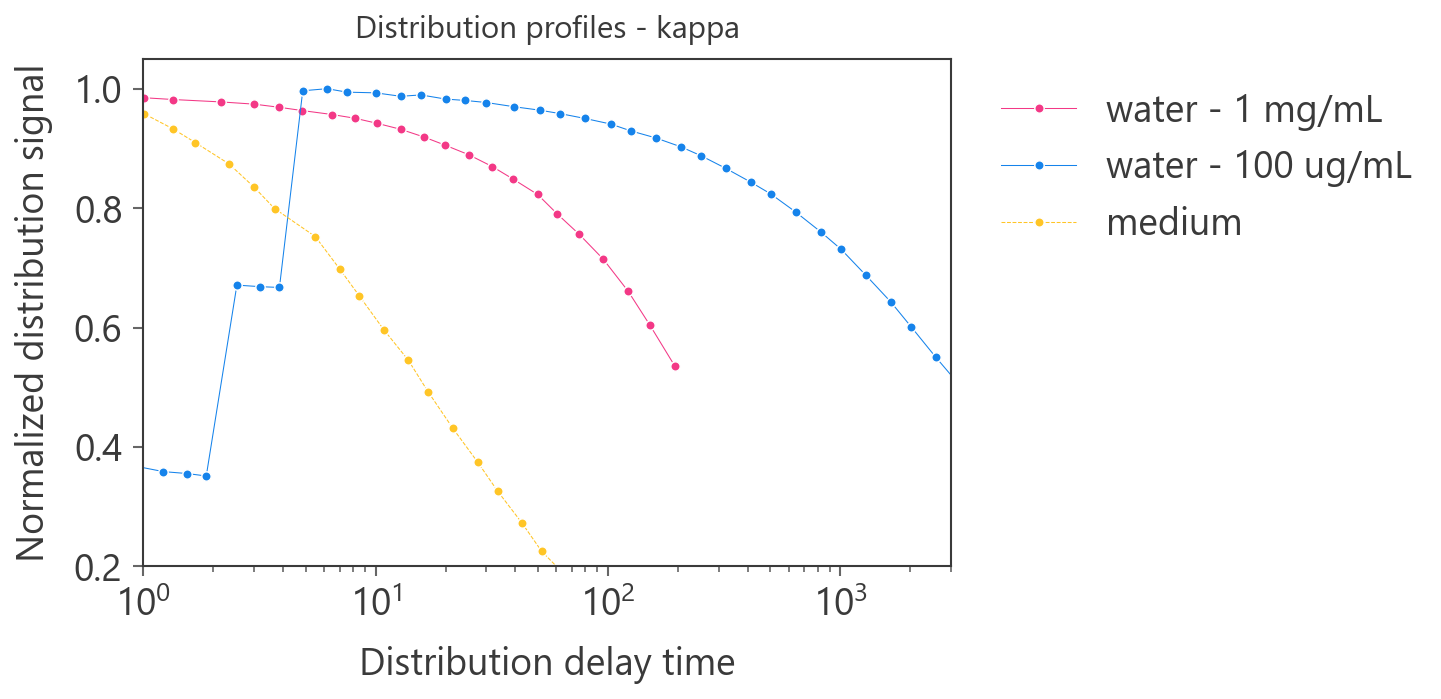

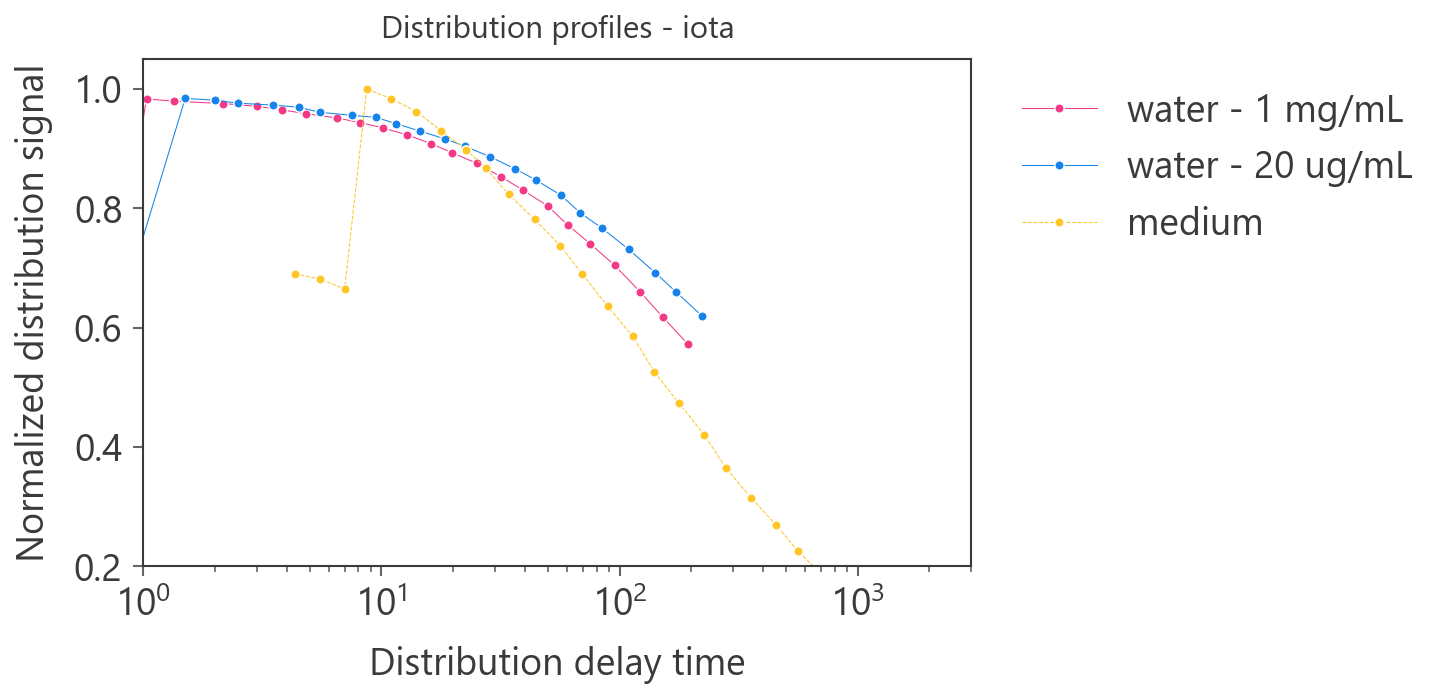

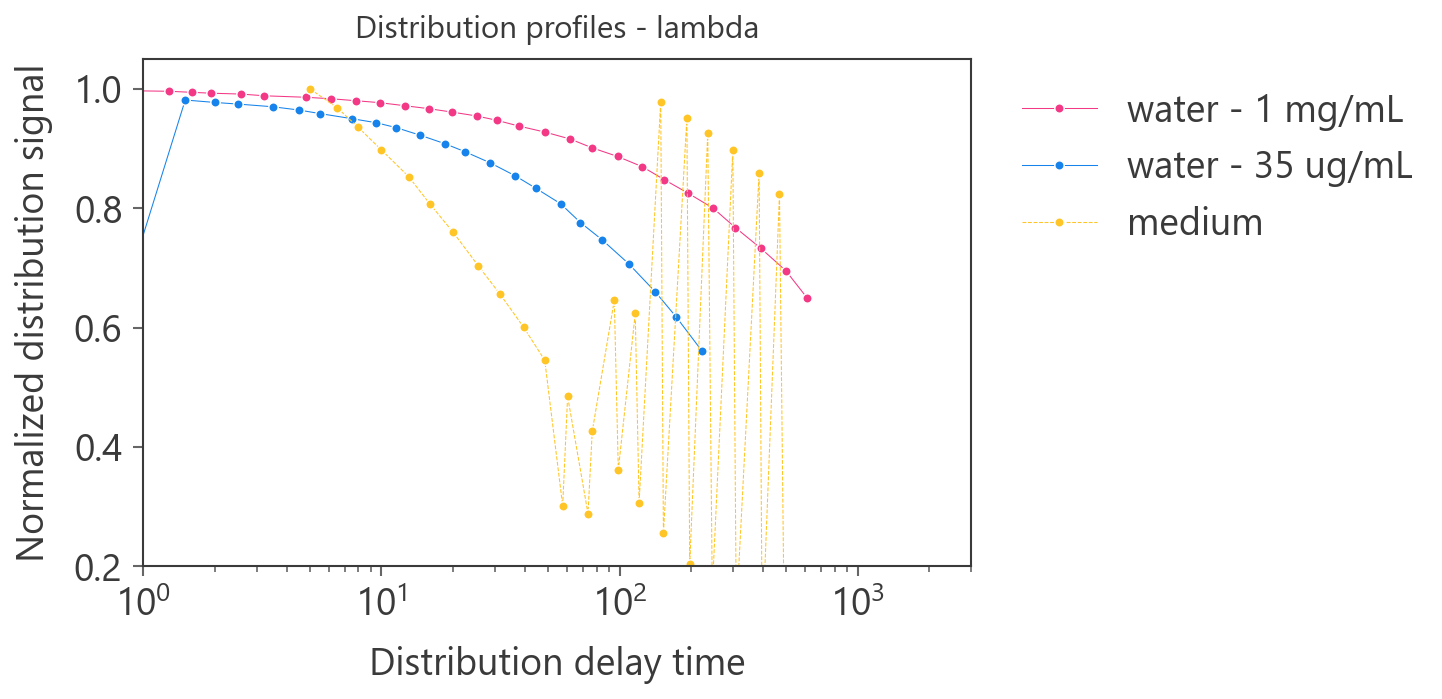

In [30]:
for carr in ["kappa", "iota", "lambda"]:
    plot_water_concentrations_vs_medium(carr)

## Simple profile metrics 

### Metrics per sample

In [31]:
distribution_metrics = (
    df_dist
    .groupby([
        "Sample_Name",
        "sample_base",
        "carrageenan",
        "matrix",
        "concentration_label",
        "replicate"
    ], dropna=False)
    .agg(
        dist_signal_max=("distribution_fit_data", "max"),
        dist_signal_mean=("distribution_fit_data", "mean"),
        dist_signal_std=("distribution_fit_data", "std"),
        dist_x_at_max=("distribution_delay_time", lambda s: df_dist.loc[s.index, "distribution_delay_time"].iloc[np.argmax(df_dist.loc[s.index, "distribution_fit_data"].values)] if len(s) > 0 else np.nan),
        n_points=("distribution_fit_data", "count")
    )
    .reset_index()
)

display(distribution_metrics.head())

,Sample_Name,sample_base,carrageenan,matrix,concentration_label,replicate,dist_signal_max,dist_signal_mean,dist_signal_std,dist_x_at_max,n_points
0,L_3S-1mg_mL 1,L_3S-1mg_mL,lambda,water,1 mg/mL,1.0,0.940,0.699472,0.349568,0.249,40
1,L_3S-1mg_mL 2,L_3S-1mg_mL,lambda,water,1 mg/mL,2.0,0.932,0.689661,0.347618,0.175,40
2,L_3S-1mg_mL 3,L_3S-1mg_mL,lambda,water,1 mg/mL,3.0,0.909,0.716525,0.269641,0.143,40
3,L_3S-1mg_mL-mean,NaN,NaN,NaN,NaN,NaN,0.940,0.699472,0.349568,0.249,40
4,L_3S-35ug_mL 1,L_3S-35ug_mL,lambda,water,35 ug/mL,1.0,0.807,0.593097,0.283838,0.373,40


### Metrics per group boxplot

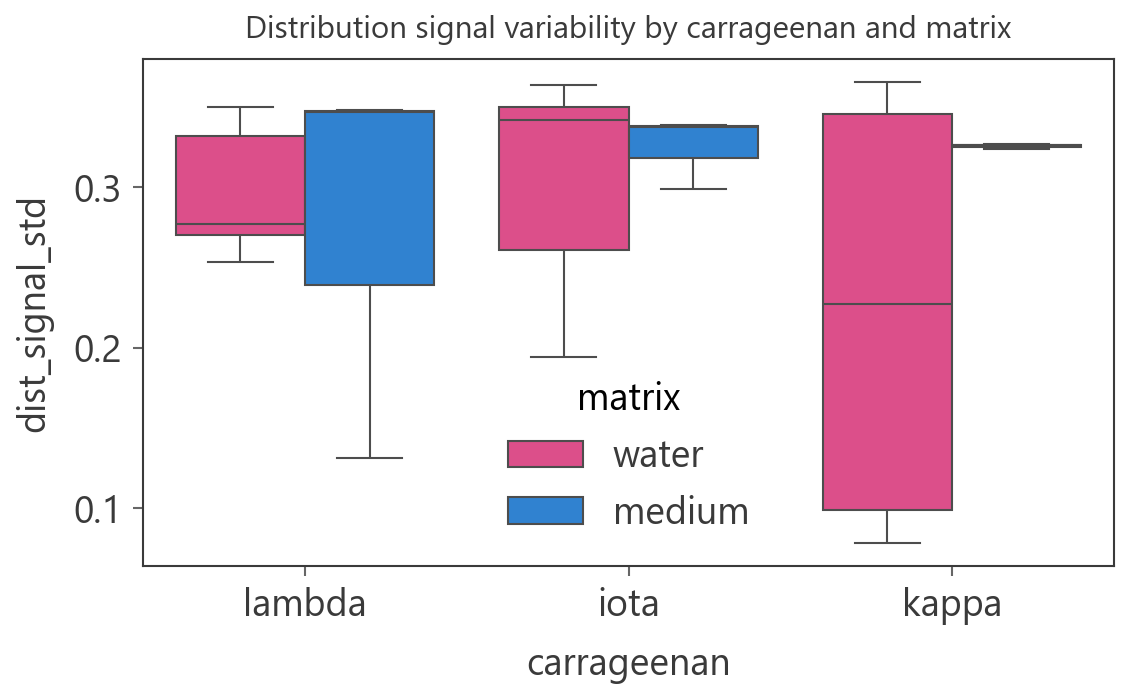

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=distribution_metrics[distribution_metrics["carrageenan"].notna()],
    x="carrageenan",
    y="dist_signal_std",
    hue="matrix"
)
plt.title("Distribution signal variability by carrageenan and matrix")
plt.tight_layout()
plt.show()

# **Autocorrelation**

##

### Basic correlation cleaning

In [33]:
df_corr = df_corr.dropna(subset=["delay_time_s", "correlation_value"]).copy()

print(df_corr.shape)
display(df_corr.head())

(8640, 9)


,Sample_Name,point_index,correlation_value,delay_time_s,sample_base,carrageenan,matrix,concentration_label,replicate
0,k_1s-100ug_mL 1,1,0.0897,0.5,k_1s-100ug_mL,kappa,water,100 ug/mL,1.0
1,k_1s-100ug_mL 1,2,0.0946,1.0,k_1s-100ug_mL,kappa,water,100 ug/mL,1.0
2,k_1s-100ug_mL 1,3,0.0952,1.5,k_1s-100ug_mL,kappa,water,100 ug/mL,1.0
3,k_1s-100ug_mL 1,4,0.0967,2.0,k_1s-100ug_mL,kappa,water,100 ug/mL,1.0
4,k_1s-100ug_mL 1,5,0.0949,2.5,k_1s-100ug_mL,kappa,water,100 ug/mL,1.0


### Check range

In [34]:
df_corr[["delay_time_s", "correlation_value"]].describe()

,delay_time_s,correlation_value
count,8.640000e+03,8640.000000
mean,4.019780e+06,0.188909
std,1.087239e+07,0.293071
min,5.000000e-01,0.000000
25%,2.490000e+02,0.000335
50%,1.590000e+04,0.015750
75%,9.997500e+05,0.290000
max,6.290000e+07,1.180000


### Function to plot autocorrelation

In [35]:
def plot_correlation_curves(
    df,
    title="Autocorrelation curves",
    x_col="delay_time_s",
    y_col="correlation_value",
    group_col="Sample_Name",
    alpha=0.6,
    log_x=True
):
    plt.figure(figsize=(8, 5))

    for sample_name, subdf in df.groupby(group_col):
        subdf = subdf.sort_values(x_col)
        plt.plot(subdf[x_col], subdf[y_col], lw=1.2, alpha=alpha)

    if log_x:
        plt.xscale("log")

    plt.title(title)
    plt.xlabel("Delay time (s)")
    plt.ylabel("Correlation value")
    plt.tight_layout()
    plt.show()

### Global autocorrelation in water

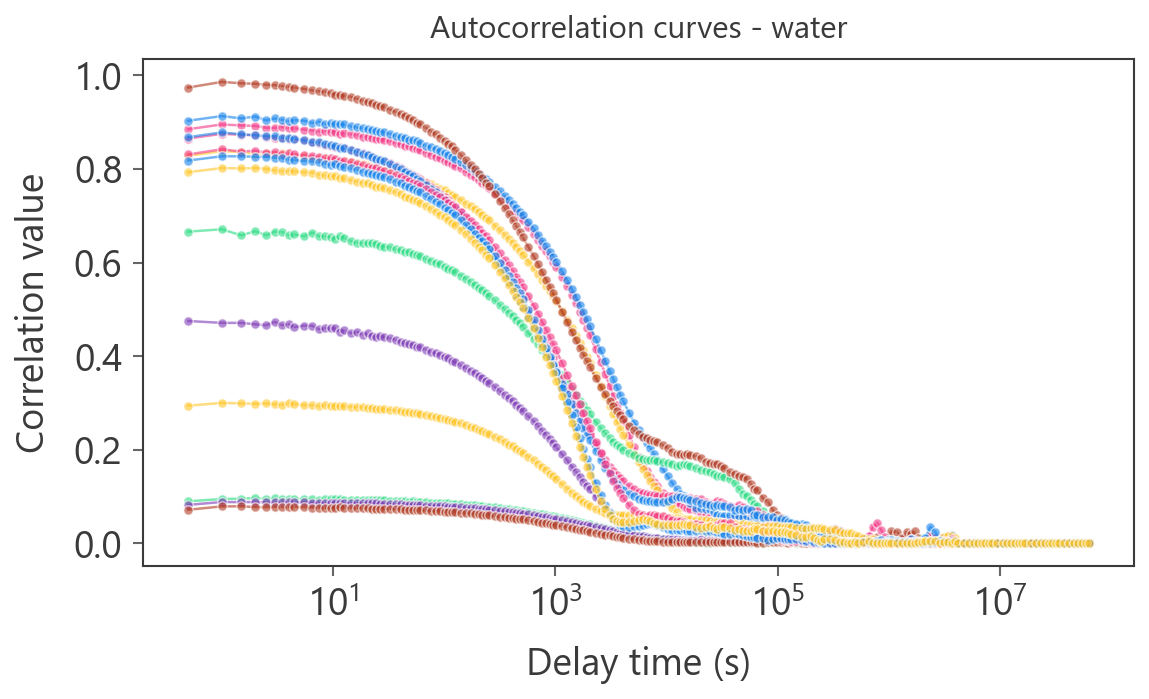

In [36]:
plot_correlation_curves(
    df_corr_water,
    title="Autocorrelation curves - water"
)

### Global autocorrelation in media

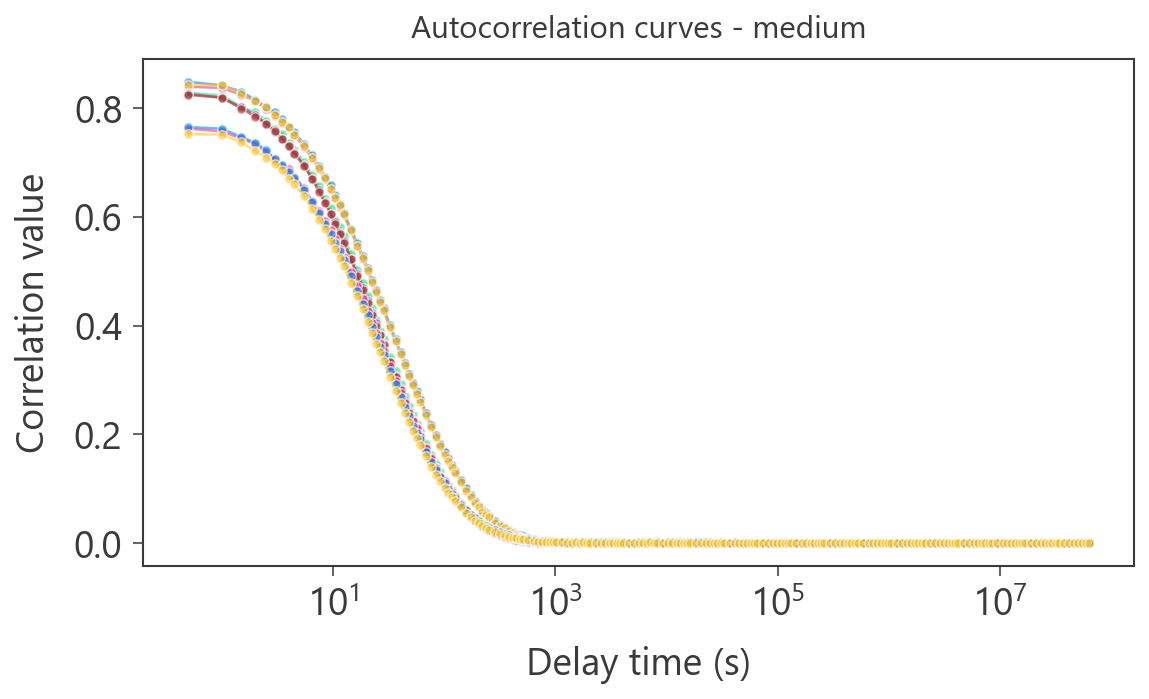

In [37]:
plot_correlation_curves(
    df_corr_medium,
    title="Autocorrelation curves - medium"
)

### Autocorrelation per carrageenan in water

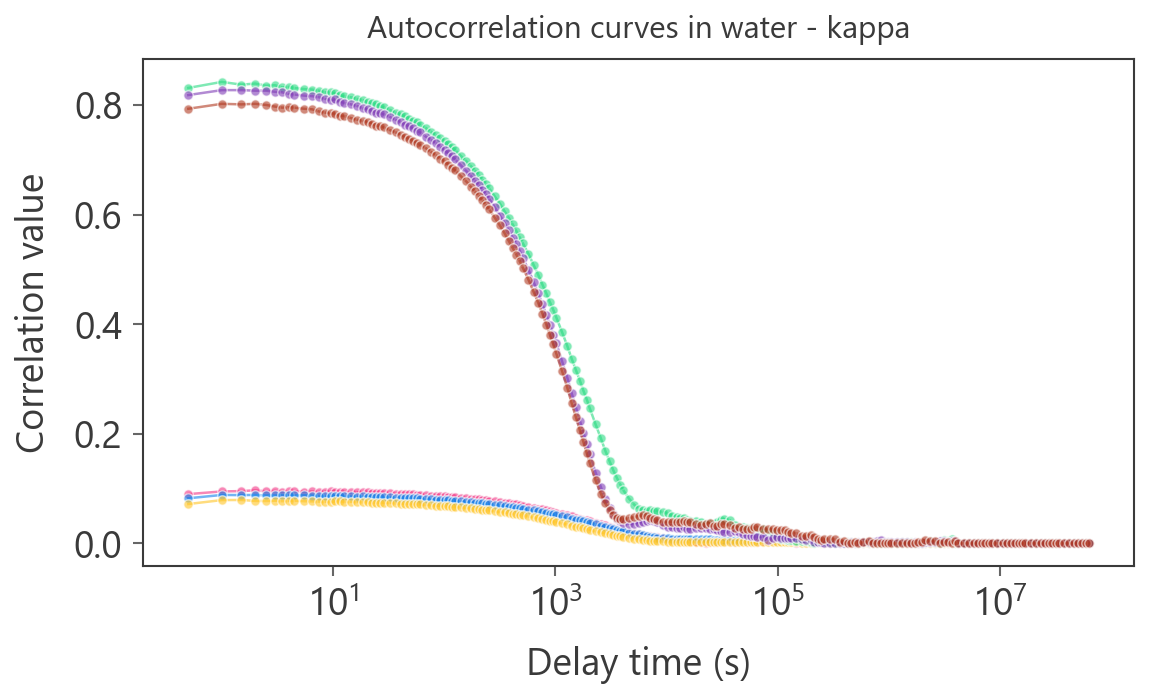

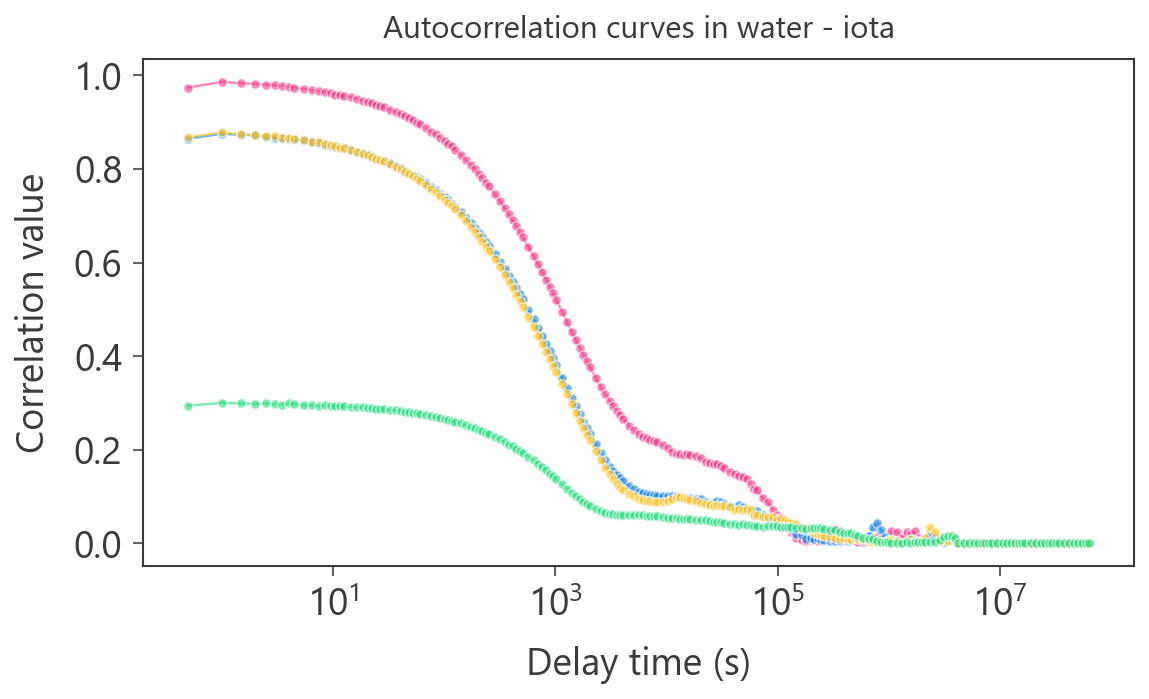

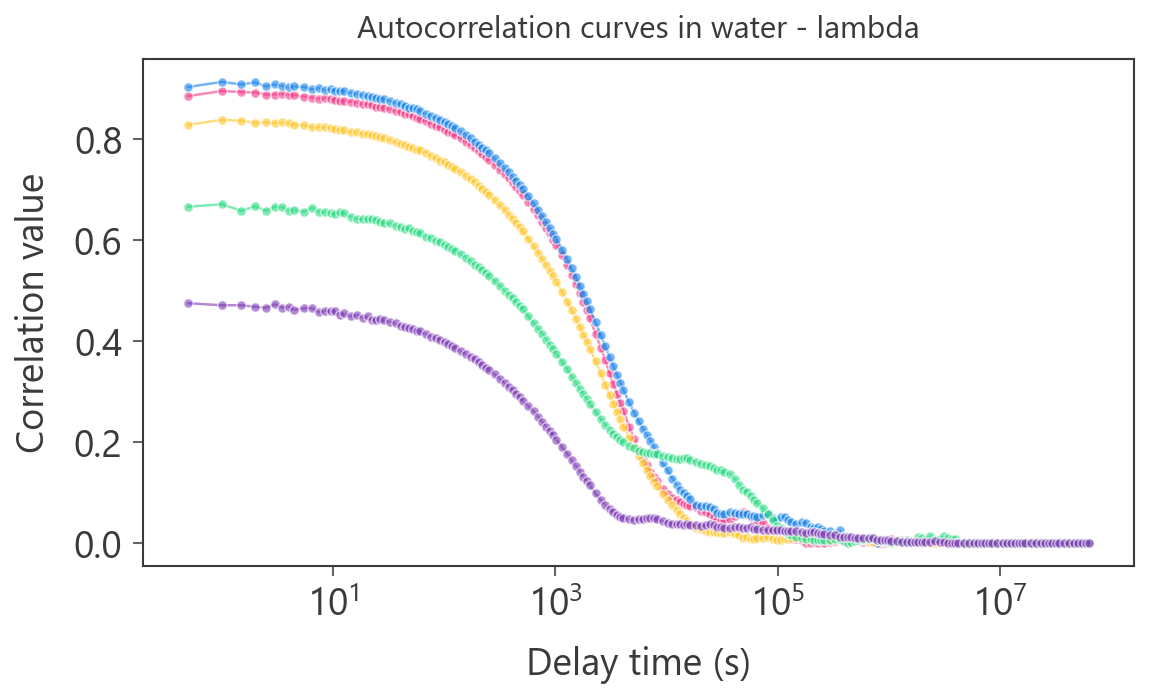

In [38]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = df_corr_water[df_corr_water["carrageenan"] == carr]
    if len(tmp) > 0:
        plot_correlation_curves(
            tmp,
            title=f"Autocorrelation curves in water - {carr}"
        )

### Autocorrelation per carrageenan in media

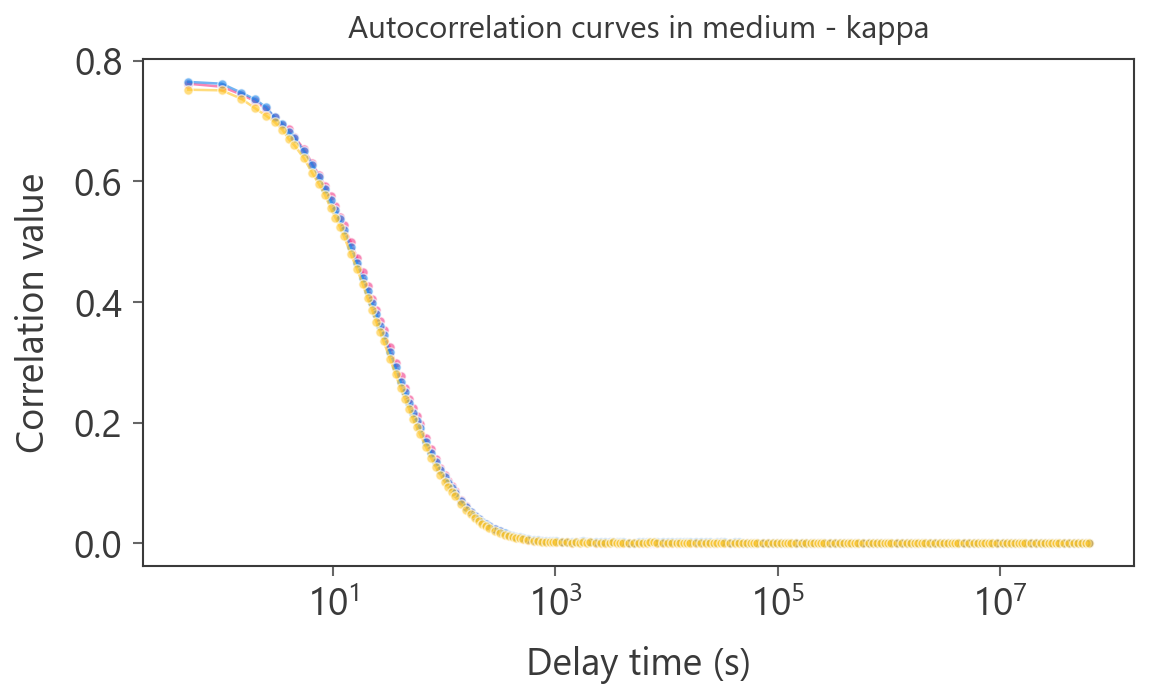

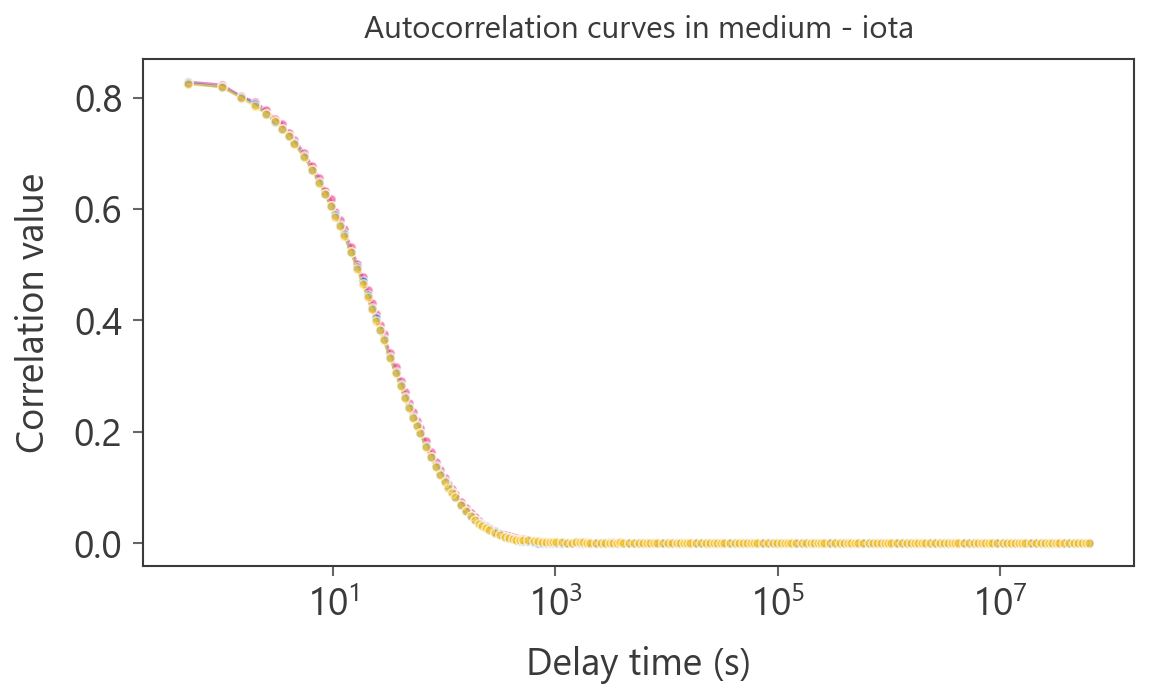

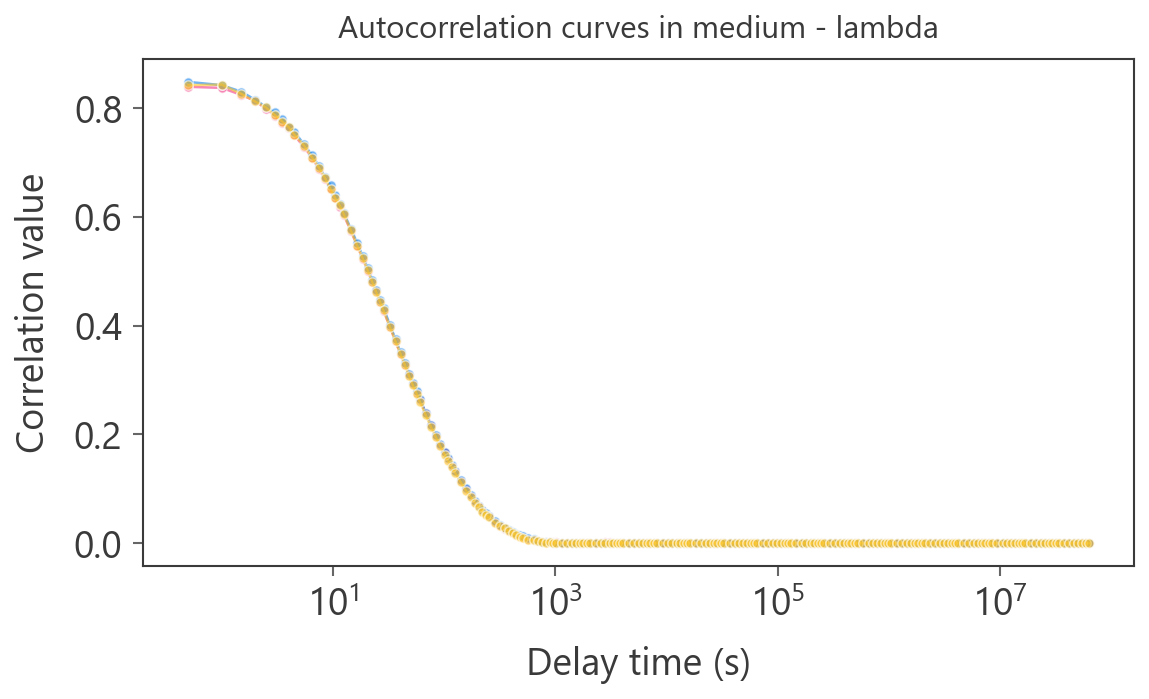

In [39]:
for carr in ["kappa", "iota", "lambda"]:
    tmp = df_corr_medium[df_corr_medium["carrageenan"] == carr]
    if len(tmp) > 0:
        plot_correlation_curves(
            tmp,
            title=f"Autocorrelation curves in medium - {carr}"
        )

## Mean **autocorrelation** profiles

### Mean per `sample_base` and `point_index`

In [40]:
corr_profile = (
    df_corr
    .groupby([
        "sample_base",
        "carrageenan",
        "matrix",
        "point_index"
    ], dropna=False)
    .agg(
        delay_time_mean=("delay_time_s", "mean"),
        corr_mean=("correlation_value", "mean"),
        corr_std=("correlation_value", "std"),
        n=("correlation_value", "count")
    )
    .reset_index()
)

display(corr_profile.head())

,sample_base,carrageenan,matrix,point_index,delay_time_mean,corr_mean,corr_std,n
0,L_3S-1mg_mL,lambda,water,1,0.5,0.872000,0.039154,3
1,L_3S-1mg_mL,lambda,water,2,1.0,0.882000,0.039154,3
2,L_3S-1mg_mL,lambda,water,3,1.5,0.879000,0.037987,3
3,L_3S-1mg_mL,lambda,water,4,2.0,0.878667,0.041633,3
4,L_3S-1mg_mL,lambda,water,5,2.5,0.875000,0.037242,3


### Function to plot autocorrelation mean profile

In [41]:
def plot_mean_correlation_profile(df, title="", hue_col="sample_base", log_x=True):
    plt.figure(figsize=(10, 5))

    for label, subdf in df.groupby(hue_col):
        subdf = subdf.sort_values("delay_time_mean")
        plt.plot(subdf["delay_time_mean"], subdf["corr_mean"], lw=1.2, alpha=0.6, label=label)

    if log_x:
        plt.xscale("log")

    plt.title(title)
    plt.xlabel("Delay time (s)"); plt.ylabel("Mean correlation value")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

### Mean profiles in water

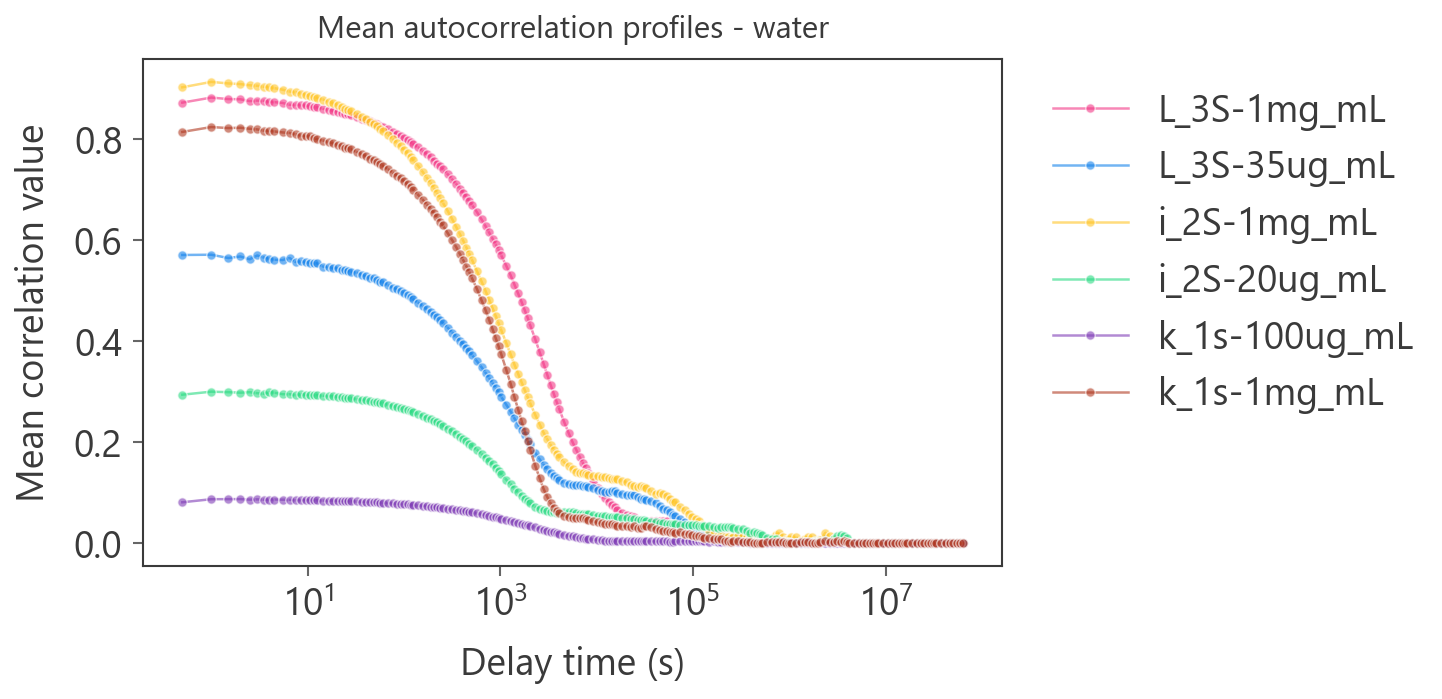

In [42]:
plot_mean_correlation_profile(
    corr_profile[
        (corr_profile["matrix"] == "water") &
        (corr_profile["carrageenan"].notna())
    ],
    title="Mean autocorrelation profiles - water"
)

### Mean profiles in media

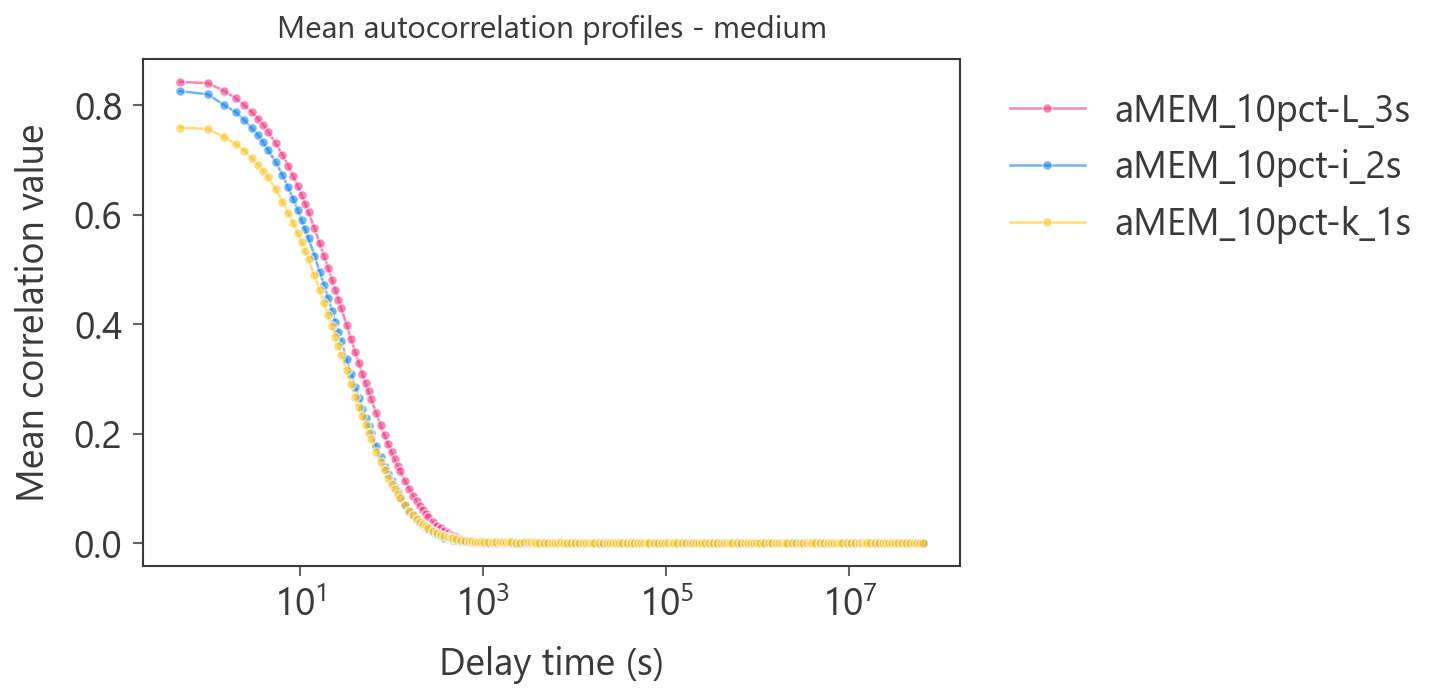

In [43]:
plot_mean_correlation_profile(
    corr_profile[
        (corr_profile["matrix"] == "medium") &
        (corr_profile["carrageenan"].notna())
    ],
    title="Mean autocorrelation profiles - medium"
)

# **Paper-ready** figure

### Mean distribution per matrix comparative plot 

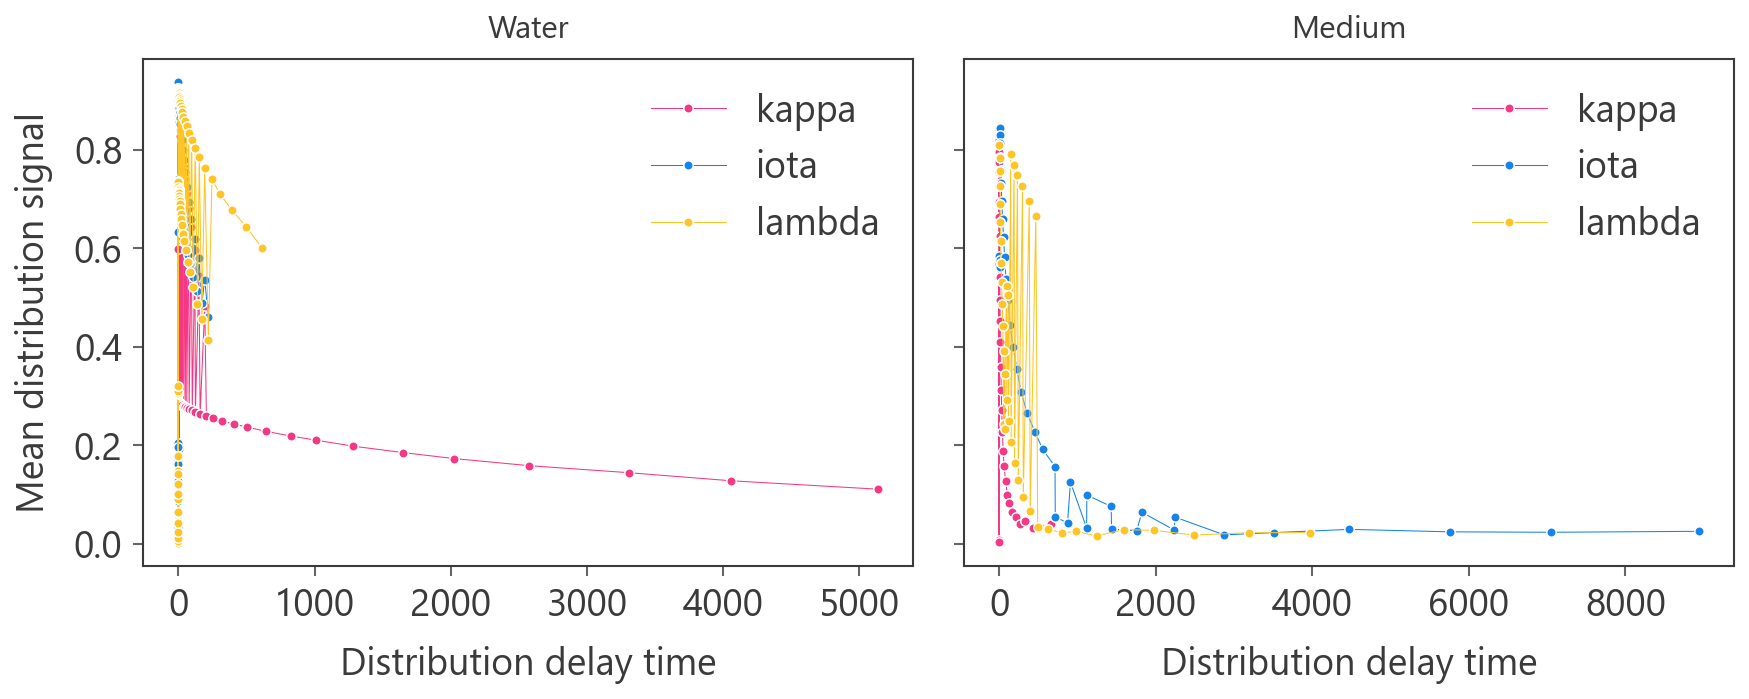

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for carr in ["kappa", "iota", "lambda"]:
    subdf = dist_profile[
        (dist_profile["matrix"] == "water") &
        (dist_profile["carrageenan"] == carr)
    ].sort_values("x_mean")
    if len(subdf) > 0:
        axes[0].plot(subdf["x_mean"], subdf["y_mean"], label=carr)

axes[0].set_title("Water")
axes[0].set_xlabel("Distribution delay time")
axes[0].set_ylabel("Mean distribution signal")
axes[0].legend()

for carr in ["kappa", "iota", "lambda"]:
    subdf = dist_profile[
        (dist_profile["matrix"] == "medium") &
        (dist_profile["carrageenan"] == carr)
    ].sort_values("x_mean")
    if len(subdf) > 0:
        axes[1].plot(subdf["x_mean"], subdf["y_mean"], label=carr)

axes[1].set_title("Medium")
axes[1].set_xlabel("Distribution delay time")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribution_profiles_water_vs_medium.png", dpi=300, bbox_inches="tight")
plt.show()

### Mean autocorrelation per matrix comparative plot 

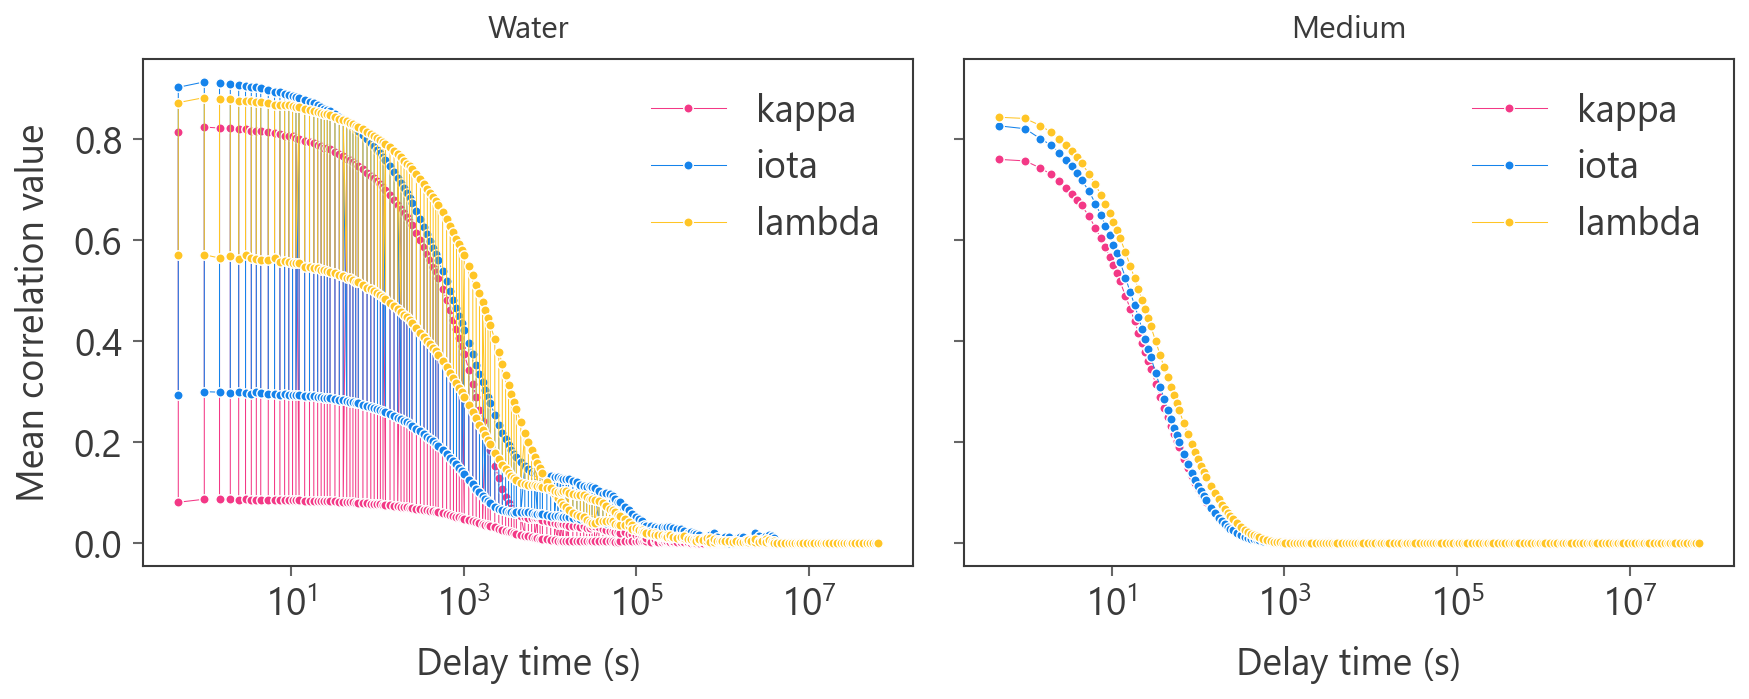

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for carr in ["kappa", "iota", "lambda"]:
    subdf = corr_profile[
        (corr_profile["matrix"] == "water") &
        (corr_profile["carrageenan"] == carr)
    ].sort_values("delay_time_mean")
    if len(subdf) > 0:
        axes[0].plot(subdf["delay_time_mean"], subdf["corr_mean"], label=carr)

axes[0].set_xscale("log")
axes[0].set_title("Water")
axes[0].set_xlabel("Delay time (s)")
axes[0].set_ylabel("Mean correlation value")
axes[0].legend()

for carr in ["kappa", "iota", "lambda"]:
    subdf = corr_profile[
        (corr_profile["matrix"] == "medium") &
        (corr_profile["carrageenan"] == carr)
    ].sort_values("delay_time_mean")
    if len(subdf) > 0:
        axes[1].plot(subdf["delay_time_mean"], subdf["corr_mean"], label=carr)

axes[1].set_xscale("log")
axes[1].set_title("Medium")
axes[1].set_xlabel("Delay time (s)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_profiles_water_vs_medium.png", dpi=300, bbox_inches="tight")
plt.show()

# Supporting exports

### Aggregated profiles saving

In [46]:
dist_profile.to_csv(DATA_PROCESSED_DIR / "distribution_profiles_summary.csv", index=False)
distribution_metrics.to_csv(DATA_PROCESSED_DIR / "distribution_metrics.csv", index=False)
corr_profile.to_csv(DATA_PROCESSED_DIR / "correlation_profiles_summary.csv", index=False)

# **Interpretation Summary** | Distribution and Autocorrelation Analysis

## Distribution profiles

Distribution analysis complements Z-average and PDI measurements, particularly in systems exhibiting high heterogeneity and broad size distributions.

In aqueous systems, the profiles clearly reflect large and heterogeneous carrageenan-derived structures, consistent with the elevated Z-average and PDI values previously observed. Among the samples, λ-carrageenan exhibits the broadest distributions, suggesting a more complex and potentially multimodal supramolecular organization.

In biological medium, the distribution profiles shift markedly toward smaller apparent sizes, with a strong reduction in differences among carrageenan types. This behavior indicates that the scattering signal becomes dominated by the medium itself, most likely due to serum proteins and/or small protein-associated complexes.

## Autocorrelation curves

Autocorrelation analysis provides an additional qualitative measure of sample dynamics and complexity.

In water, the curves display slower decays and broader profiles, consistent with the presence of larger hydrodynamic structures. Clear differences among κ-, ι-, and λ-carrageenans are observed, suggesting distinct aggregation or organizational regimes.

In medium, the autocorrelation curves exhibit faster and highly similar decays across all carrageenan types. This convergence strongly supports the interpretation that the colloidal behavior is dominated by the medium, with reduced contribution from large carrageenan assemblies.

## Overall interpretation

Taken together, distribution and autocorrelation analyses provide consistent evidence that:

1. Carrageenans form large and heterogeneous supramolecular assemblies in aqueous environments.
2. These assemblies are not preserved under biologically relevant medium conditions.
3. In medium, the DLS response becomes largely governed by the surrounding matrix.
4. Consequently, DLS measurements in water should not be directly extrapolated to represent the physicochemical state of carrageenans during in vitro exposure.

These findings highlight the critical role of matrix composition in modulating the colloidal organization of sulfated polysaccharides, with direct implications for their biological presentation and interaction with cells.